# Data gathering and preprocessing

## Imports

In [1]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from typing import Any
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
dataFrame = pd.read_csv("./Dataset/hotel_bookings.csv").sample(30000, random_state=268555)
# dataFrame = pd.read_csv("./Dataset/hotel_bookings.csv")

c:\Users\kkacp\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data checks

### Understanding given data

In [2]:
dataFrame.info()

def printMissingDataSummary(givenDataFrame: pd.DataFrame) -> None:
    missingCount = givenDataFrame.isna().sum()
    missingPercentage = (missingCount / len(givenDataFrame) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(dataFrame)

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 25367 to 3740
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           30000 non-null  object 
 1   is_canceled                     30000 non-null  int64  
 2   lead_time                       30000 non-null  int64  
 3   arrival_date_year               30000 non-null  int64  
 4   arrival_date_month              30000 non-null  object 
 5   arrival_date_week_number        30000 non-null  int64  
 6   arrival_date_day_of_month       30000 non-null  int64  
 7   stays_in_weekend_nights         30000 non-null  int64  
 8   stays_in_week_nights            30000 non-null  int64  
 9   adults                          30000 non-null  int64  
 10  children                        29999 non-null  float64
 11  babies                          30000 non-null  int64  
 12  meal                            30

### Dealing with missing data #1

In [3]:
dataFrame.drop(columns=["company"], inplace=True)
dataFrame = dataFrame.loc[dataFrame["country"].notna()].copy()
dataFrame = dataFrame.loc[dataFrame["children"].notna()].copy()

### Dealing with time in data

In [4]:
def getMonthMap() -> dict[str, int]:
    return {
        "January": 1,
        "February": 2,
        "March": 3,
        "April": 4,
        "May": 5,
        "June": 6,
        "July": 7,
        "August": 8,
        "September": 9,
        "October": 10,
        "November": 11,
        "December": 12,
    }


def buildArrivalDate(givenDataFrame: pd.DataFrame) -> pd.Series:
    return pd.to_datetime(
        {
            "year": givenDataFrame["arrival_date_year"],
            "month": givenDataFrame["arrival_date_month"],
            "day": givenDataFrame["arrival_date_day_of_month"],
        },
        errors="coerce"
    )


def checkTimeDataConsistency(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    checkOutDf = givenDataFrame.loc[givenDataFrame["reservation_status"] == "Check-Out"].copy()
    daysDiff = (checkOutDf["reservation_status_date"] - checkOutDf["arrival_date"]).dt.days
    expectedNights = checkOutDf["stays_in_week_nights"] + checkOutDf["stays_in_weekend_nights"]

    invalidIndex = checkOutDf.index[daysDiff != expectedNights]
    if len(invalidIndex) > 0:
        print(f"Dropped invalid rows: {len(invalidIndex)}")

    return givenDataFrame.drop(index=invalidIndex).copy()


def prepareTimeColumns(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    currentDf = givenDataFrame.copy()
    currentDf["reservation_status_date"] = pd.to_datetime(currentDf["reservation_status_date"], errors="coerce")
    currentDf["arrival_date_month"] = currentDf["arrival_date_month"].map(getMonthMap())
    currentDf["arrival_date"] = buildArrivalDate(currentDf)

    currentDf = checkTimeDataConsistency(currentDf)
    currentDf = currentDf[currentDf["arrival_date"].notna()].copy()
    currentDf.drop(columns=["arrival_date_year", "arrival_date_month", "arrival_date_day_of_month"], inplace=True)
    return currentDf


dataFrame = prepareTimeColumns(dataFrame)

Dropped invalid rows: 10


### Dealing with orphans

In [5]:
dataFrame = dataFrame[dataFrame['adults'] != 0]

### Dealing with missing data #2

In [6]:
def splitAgentDatasets(givenDataFrame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    currentDataFrame = givenDataFrame.copy()
    trainDf = currentDataFrame[currentDataFrame["agent"].notna()].copy()
    predictDf = currentDataFrame[currentDataFrame["agent"].isna()].copy()
    return trainDf, predictDf


def buildAgentFeatureSets(trainDf: pd.DataFrame, predictDf: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    y = trainDf["agent"]
    X = trainDf.drop(columns=["agent"])
    predX = predictDf.drop(columns=["agent"])
    return X, y, predX


def getFeatureColumns(X: pd.DataFrame) -> tuple[list[str], list[str]]:
    catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numCols = X.select_dtypes(include=["number"]).columns.tolist()
    return catCols, numCols


def buildAgentPipeline(catCols: list[str], numCols: list[str]) -> Any:
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
            ("num", "passthrough", numCols),
        ]
    )

    return sklearn.pipeline.Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
    ])


def trainAndValidateAgentModel(model: Any, X: pd.DataFrame, y: pd.Series) -> Any:
    trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=268555
    )
    model.fit(trainX, trainY)
    print("val score:", model.score(valX, valY))
    return model


def predictMissingAgents(givenDataFrame: pd.DataFrame) -> np.ndarray:
    trainDf, predictDf = splitAgentDatasets(givenDataFrame)

    X, y, predX = buildAgentFeatureSets(trainDf, predictDf)
    catCols, numCols = getFeatureColumns(X)
    model = buildAgentPipeline(catCols, numCols)
    model = trainAndValidateAgentModel(model, X, y)
    return model.predict(predX)


predictedAgents = predictMissingAgents(dataFrame)
if len(predictedAgents) > 0:
    dataFrame.loc[dataFrame["agent"].isna(), "agent"] = predictedAgents

val score: 0.8311335403726708


In [7]:
printMissingDataSummary(dataFrame)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
is_canceled                                0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancella

In [8]:
def printColumnValueCounts(givenDataFrame: pd.DataFrame) -> None:
    print(givenDataFrame.nunique(dropna=False))

    rows = []
    for col in givenDataFrame.columns:
        counts = givenDataFrame[col].value_counts(dropna=False).sort_values(ascending=False)
        rows.extend(
            {"column": col, "value": str(val), "count": int(cnt)}
            for val, cnt in counts.items()
        )

    result = pd.DataFrame(rows)
    result.to_csv("./Dataset/column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(dataFrame)

hotel                                2
is_canceled                          2
lead_time                          465
arrival_date_week_number            53
stays_in_weekend_nights             11
stays_in_week_nights                25
adults                               9
children                             5
babies                               3
meal                                 5
country                            140
market_segment                       7
distribution_channel                 4
is_repeated_guest                    2
previous_cancellations              14
previous_bookings_not_canceled      42
reserved_room_type                   9
assigned_room_type                  10
booking_changes                     12
deposit_type                         3
agent                              277
days_in_waiting_list               101
customer_type                        4
adr                               4304
required_car_parking_spaces          4
total_of_special_requests

### Correlation matrix presentation

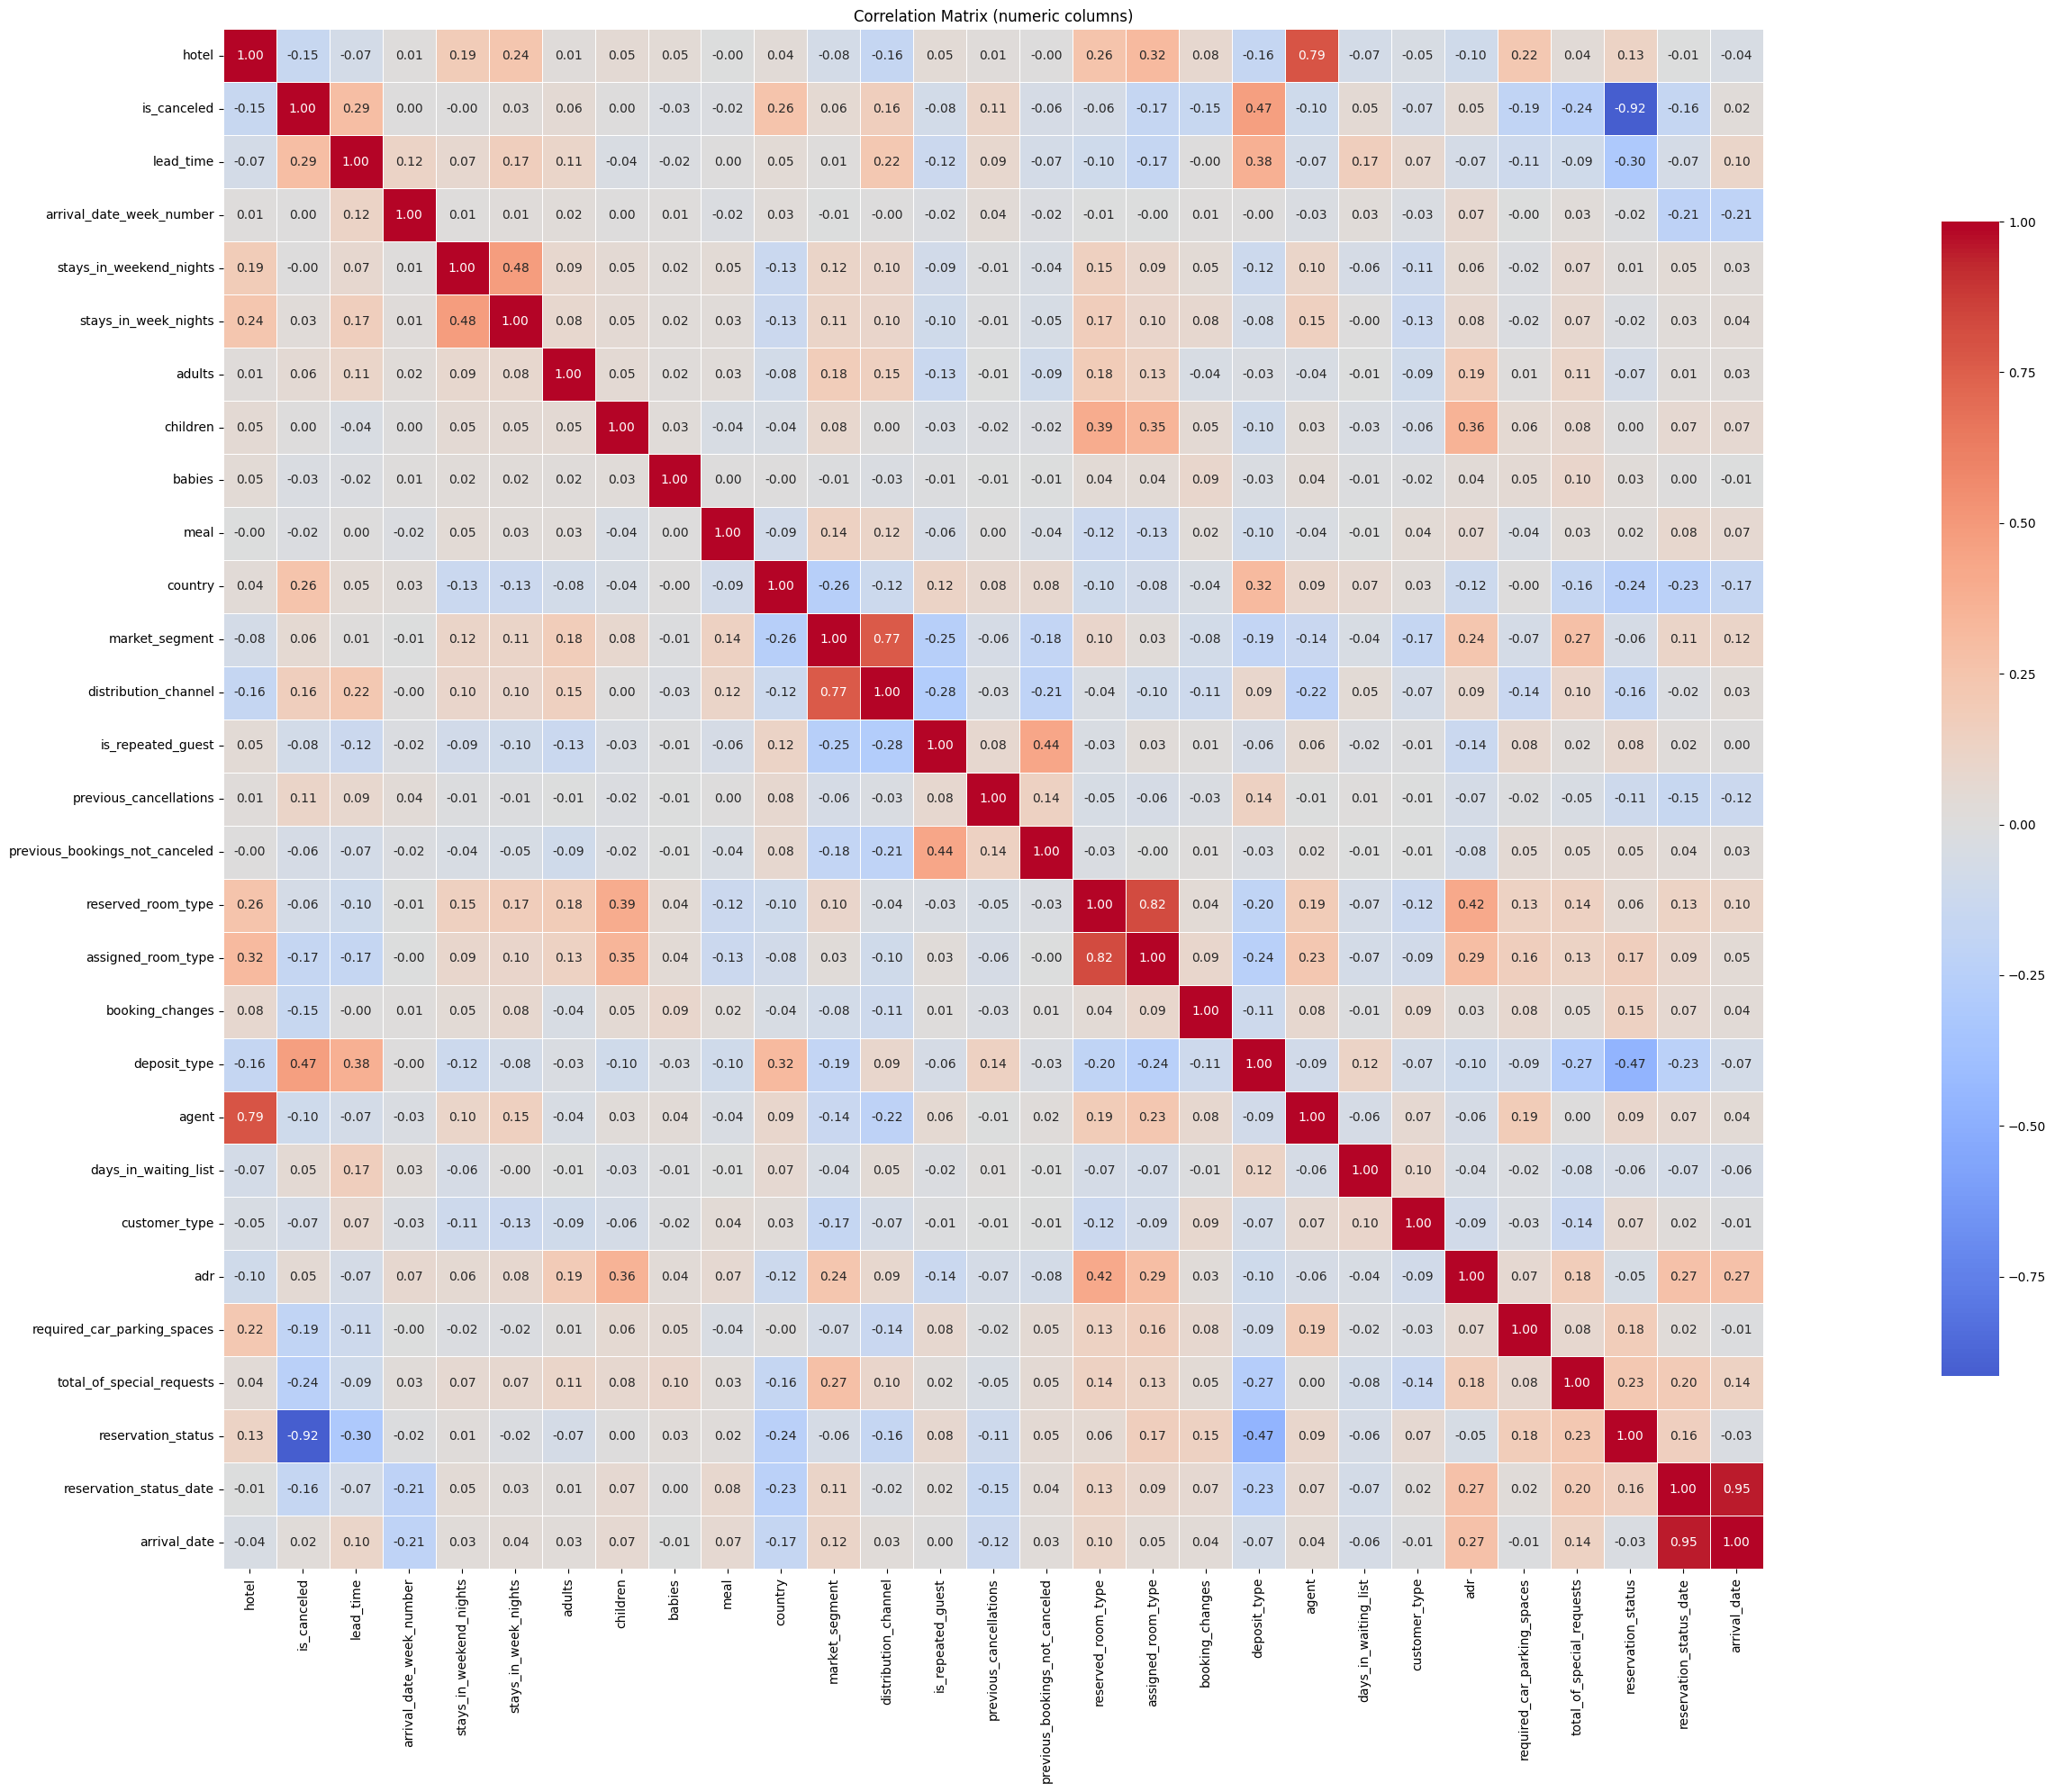


Pairs with |correlation| > 0.4:
              feature_a                      feature_b   corr
reservation_status_date                   arrival_date  0.955
            is_canceled             reservation_status -0.915
     reserved_room_type             assigned_room_type  0.822
                  hotel                          agent  0.786
         market_segment           distribution_channel  0.766
stays_in_weekend_nights           stays_in_week_nights  0.483
            is_canceled                   deposit_type  0.469
           deposit_type             reservation_status -0.469
      is_repeated_guest previous_bookings_not_canceled  0.436
     reserved_room_type                            adr  0.421


In [9]:
def encodeNonNumericForCorr(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    currentDataFrame = givenDataFrame.copy()
    for col in currentDataFrame.select_dtypes(include=["object", "datetime64[ns]"]).columns:
        currentDataFrame[col] = currentDataFrame[col].astype("category").cat.codes
    return currentDataFrame


def plotCorrHeatmap(corr: pd.DataFrame) -> None:
    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
    plt.show()


def extractStrongCorrPairs(corr: pd.DataFrame, threshold: float = 0.4) -> pd.DataFrame:
    upperMask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    corrPairs = corr.where(upperMask).stack().reset_index()
    corrPairs.columns = ["feature_a", "feature_b", "corr"]

    strongPairs = corrPairs.loc[corrPairs["corr"].abs() > threshold].copy()
    strongPairs = strongPairs.sort_values("corr", key=lambda s: s.abs(), ascending=False)
    return strongPairs


def printStrongCorrPairs(strongPairs: pd.DataFrame, threshold: float = 0.4) -> None:
    print(f"\nPairs with |correlation| > {threshold}:")
    if strongPairs.empty:
        print("No pairs satisfy the condition.")
        return

    print(strongPairs.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


def printComputationMatrix(givenDataFrame: pd.DataFrame) -> None:
    encodedDf = encodeNonNumericForCorr(givenDataFrame)
    corr = encodedDf.corr(numeric_only=True)

    plotCorrHeatmap(corr)
    strongPairs = extractStrongCorrPairs(corr, threshold=0.4)
    printStrongCorrPairs(strongPairs, threshold=0.4)


printComputationMatrix(dataFrame)

In [10]:
dataFrame.drop(columns=["is_canceled"], inplace=True)

In [11]:
# ADR statistics and maximum occupancy by assigned_room_type for each hotel.
def prepareRoomSummaryBase(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    baseDf = givenDataFrame.copy()
    baseDf["arrival_date"] = pd.to_datetime(baseDf["arrival_date"], errors="coerce")
    baseDf["total_nights"] = (
        baseDf["stays_in_week_nights"].fillna(0) +
        baseDf["stays_in_weekend_nights"].fillna(0)
    ).astype(int)

    workDf = baseDf[["hotel", "assigned_room_type", "arrival_date", "total_nights", "adr"]].copy()
    workDf = workDf.dropna(subset=["hotel", "assigned_room_type", "arrival_date", "adr"])
    return workDf[workDf["total_nights"] > 0].copy()


def aggregateAdrByRoomType(workDf: pd.DataFrame) -> pd.DataFrame:
    # For minimum ADR, use only positive values (exclude zeros and negatives).
    return (
        workDf.groupby(["hotel", "assigned_room_type"], as_index=False)["adr"]
        .agg(
            adr_mean="mean",
            adr_median="median",
            adr_min=lambda values: values.loc[values > 0].min(),
            adr_max="max"
        )
    )


def expandStaysToDays(workDf: pd.DataFrame) -> pd.DataFrame:
    # Expand stays to day-level rows to compute daily occupancy.
    expandedDf = workDf.loc[workDf.index.repeat(workDf["total_nights"])].copy()
    expandedDf["day_offset"] = expandedDf.groupby(level=0).cumcount()
    expandedDf["stay_date"] = expandedDf["arrival_date"] + pd.to_timedelta(expandedDf["day_offset"], unit="D")
    return expandedDf


def getMaxOccupancyByRoomType(expandedDf: pd.DataFrame) -> pd.DataFrame:
    dailyByRoom = (
        expandedDf.groupby(["hotel", "assigned_room_type", "stay_date"]).size()
        .rename("occupied_rooms")
        .reset_index()
    )

    return (
        dailyByRoom.groupby(["hotel", "assigned_room_type"], as_index=False)["occupied_rooms"]
        .max()
        .rename(columns={"occupied_rooms": "max_occupied_rooms"})
    )


def buildRoomSummaryTable(adrByRoomType: pd.DataFrame, maxOccupancyByRoomType: pd.DataFrame) -> pd.DataFrame:
    summaryDf = (
        adrByRoomType
        .merge(maxOccupancyByRoomType, on=["hotel", "assigned_room_type"], how="left")
        .sort_values(["hotel", "assigned_room_type"])
    )
    summaryDf["adr_mean"] = summaryDf["adr_mean"].round(2)
    return summaryDf


def printRoomSummary(summaryDf: pd.DataFrame) -> None:
    for hotelName in sorted(summaryDf["hotel"].unique()):
        print(f"\n{hotelName}:")
        hotelDf = summaryDf.loc[
            summaryDf["hotel"] == hotelName,
            ["assigned_room_type", "adr_mean", "adr_median", "adr_min", "adr_max", "max_occupied_rooms"]
        ].copy()
        print(hotelDf.to_string(index=False))


def printRoomTypeSummary(givenDataFrame: pd.DataFrame) -> None:
    workDf = prepareRoomSummaryBase(givenDataFrame)
    adrByRoomType = aggregateAdrByRoomType(workDf)
    expandedDf = expandStaysToDays(workDf)
    maxOccupancyByRoomType = getMaxOccupancyByRoomType(expandedDf)
    summaryDf = buildRoomSummaryTable(adrByRoomType, maxOccupancyByRoomType)
    printRoomSummary(summaryDf)


printRoomTypeSummary(dataFrame)


City Hotel:
assigned_room_type  adr_mean  adr_median  adr_min  adr_max  max_occupied_rooms
                 A     96.81      94.500     1.00   290.00                 132
                 B     96.29      93.560     1.00   235.45                  10
                 C    112.50     106.000    65.00   199.00                   2
                 D    122.40     122.450     1.48   365.00                  44
                 E    148.04     150.000    18.00   275.00                  11
                 F    176.89     180.000    18.00   316.00                  10
                 G    199.65     215.175    37.07   338.00                   5
                 K     95.78      99.000     6.00   193.00                   3

Resort Hotel:
assigned_room_type  adr_mean  adr_median  adr_min  adr_max  max_occupied_rooms
                 A     82.46      66.000      5.0   337.00                  63
                 B     98.70      88.000     29.0   201.00                   1
                 C    11

In [12]:
# Map assigned_room_type to a hotel-specific price segment by modifying dataFrame in place.
def remapAssignedRoomTypeInplace(givenDataFrame: pd.DataFrame) -> None:
    segmentRules = {
        "City Hotel": {
            "Cheap": ["A", "B", "K"],
            "Expensive": ["C", "D", "E", "F", "G"],
        },
        "Resort Hotel": {
            "Cheap": ["A", "B", "D", "I"],
            "Expensive": ["C", "E", "F", "G", "H"],
        },
    }

    for hotelName, roomSegments in segmentRules.items():
        hotelMask = givenDataFrame["hotel"] == hotelName
        for segmentName, roomTypes in roomSegments.items():
            segmentMask = hotelMask & givenDataFrame["assigned_room_type"].isin(roomTypes)
            givenDataFrame.loc[segmentMask, "assigned_room_type"] = segmentName

    print("Updated assigned_room_type directly in dataFrame.")
    print(givenDataFrame.groupby(["hotel", "assigned_room_type"]).size().to_string())


remapAssignedRoomTypeInplace(dataFrame)

Updated assigned_room_type directly in dataFrame.
hotel         assigned_room_type
City Hotel    Cheap                 14855
              Expensive              5033
Resort Hotel  Cheap                  6812
              Expensive              3054


In [13]:
printRoomTypeSummary(dataFrame)


City Hotel:
assigned_room_type  adr_mean  adr_median  adr_min  adr_max  max_occupied_rooms
             Cheap     96.79        94.5     1.00    290.0                 134
         Expensive    133.44       130.5     1.48    365.0                  53

Resort Hotel:
assigned_room_type  adr_mean  adr_median  adr_min  adr_max  max_occupied_rooms
             Cheap     84.31        68.0      2.0   350.75                  80
         Expensive    123.98       106.1      2.0   426.25                  39


### Additional visualizations (red-green style)

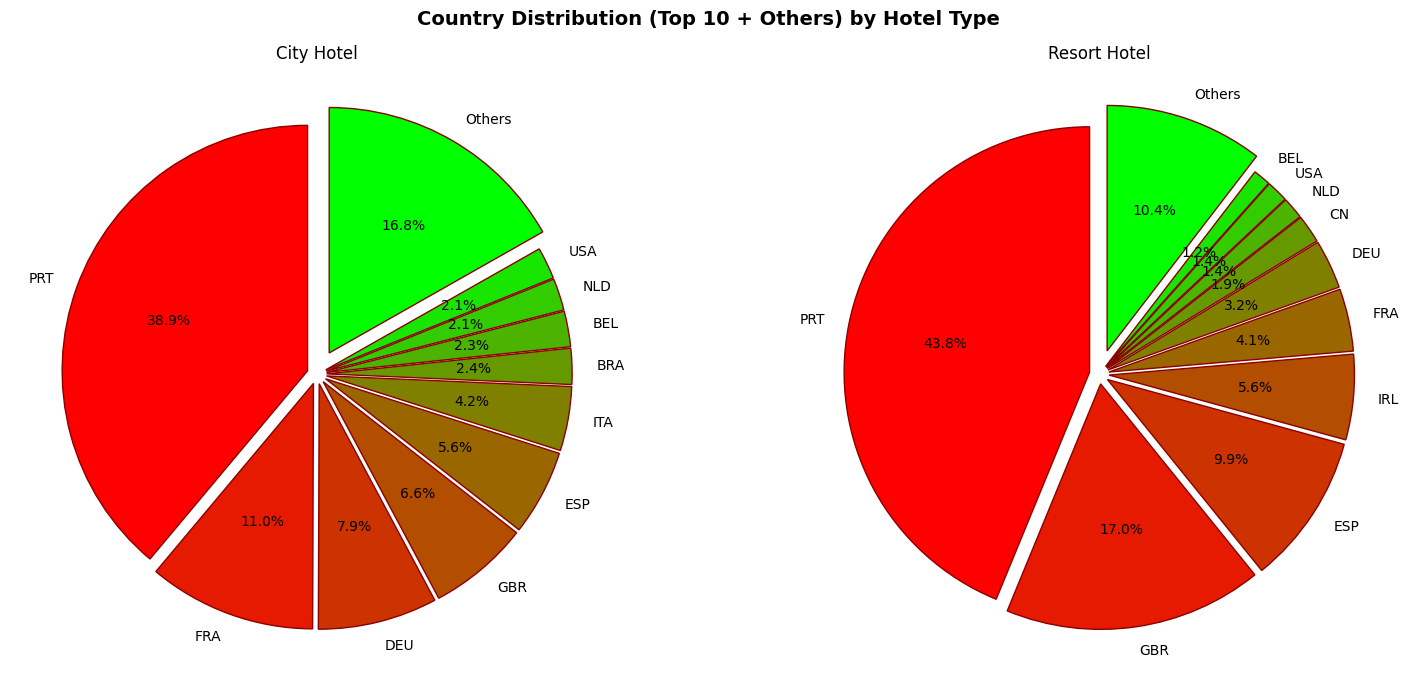

In [14]:
# I honestly hate this plot, please make it look good Roch
def plotCountryDistribution(givenDataFrame: pd.DataFrame) -> None:
    hotelValues = sorted(givenDataFrame["hotel"].dropna().unique())
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Country Distribution (Top 10 + Others) by Hotel Type", fontsize=14, fontweight="bold")

    for idx, hotelName in enumerate(hotelValues):
        hotelDf = givenDataFrame.loc[givenDataFrame["hotel"] == hotelName].copy()
        countryCounts = hotelDf["country"].value_counts(dropna=False)

        if countryCounts.empty:
            continue

        topN = 10
        pieSeries = countryCounts.head(topN).copy()
        othersCount = countryCounts.iloc[topN:].sum()
        if othersCount > 0:
            pieSeries.loc["Others"] = othersCount

        nSlices = len(pieSeries)
        colorScale = [(1 - t, t, 0) for t in np.linspace(0, 1, nSlices)]

        explode = [0.04] * nSlices
        if "Others" in pieSeries.index:
            explode[list(pieSeries.index).index("Others")] = 0.1

        ax = axes[idx]
        ax.pie(
            pieSeries.values,
            labels=pieSeries.index.astype(str),
            autopct="%1.1f%%",
            startangle=90,
            colors=colorScale,
            explode=explode,
            wedgeprops={"edgecolor": "#8b0000", "linewidth": 1.0}
        )
        ax.set_title(f"{hotelName}")

    plt.tight_layout()
    plt.show()

plotCountryDistribution(dataFrame)

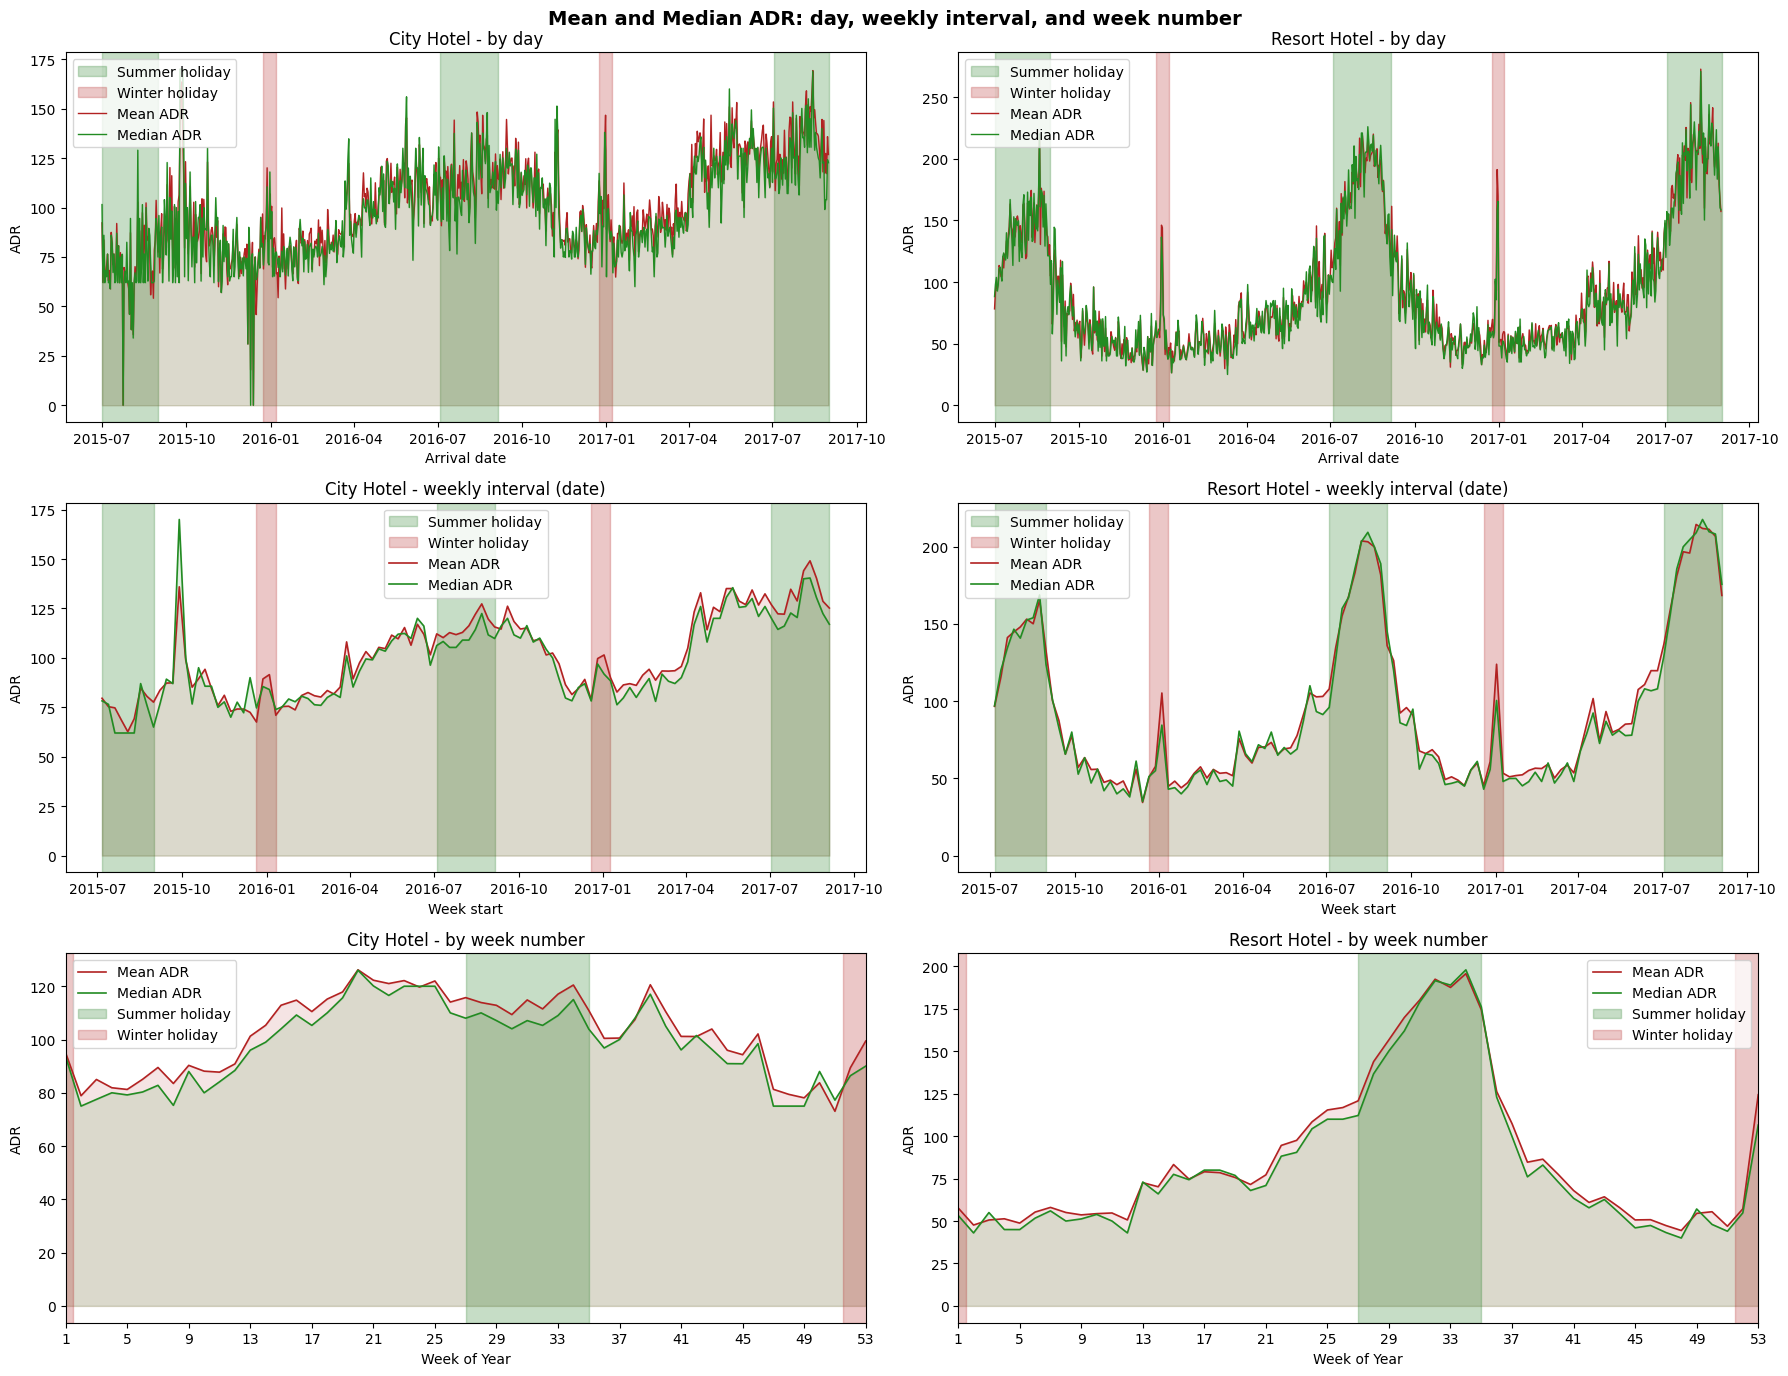

In [15]:
# ADR: 3x2 plots (daily, weekly-date, week-number) with holiday ranges.

def buildAdrPlotBase(givenDataFrame: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    plotDf = givenDataFrame.copy()
    plotDf["arrival_date"] = pd.to_datetime(plotDf["arrival_date"], errors="coerce")
    plotDf = plotDf.dropna(subset=["hotel", "arrival_date", "adr"]).copy()

    hotelValues = sorted(plotDf["hotel"].unique())
    if len(hotelValues) != 2:
        raise ValueError(f"Expected exactly 2 hotels, got {len(hotelValues)}")
    return plotDf, hotelValues


def plotAdrDaily(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    dailyAdr = (
        hotelDf.groupby("arrival_date")["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .sort_index()
        .reset_index()
    )

    dailyWeeks = dailyAdr["arrival_date"].dt.isocalendar().week.astype(int)
    dailyAdr["is_summer"] = dailyWeeks.between(27, 35)

    # Fixed winter window every year: Dec 24 - Jan 6.
    dailyMonth = dailyAdr["arrival_date"].dt.month
    dailyDay = dailyAdr["arrival_date"].dt.day
    dailyAdr["is_winter"] = ((dailyMonth == 12) & (dailyDay >= 24)) | ((dailyMonth == 1) & (dailyDay <= 6))

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        markerDf = pd.DataFrame({
            "date": pd.to_datetime(dailyAdr["arrival_date"]),
            "flag": dailyAdr[flagCol]
        }).sort_values("date")
        markerDf["group_id"] = (markerDf["flag"] != markerDf["flag"].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in markerDf.groupby("group_id"):
            if not bool(part["flag"].iloc[0]):
                continue
            startValue = part["date"].iloc[0]
            endValue = part["date"].iloc[-1] + pd.Timedelta(days=1)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.25, label=labelValue if firstLabel else None)
            firstLabel = False

    ax.plot(dailyAdr["arrival_date"], dailyAdr["adr_mean"], color="#b22222", linewidth=1.0, label="Mean ADR")
    ax.plot(dailyAdr["arrival_date"], dailyAdr["adr_median"], color="#228b22", linewidth=1.0, label="Median ADR")
    ax.fill_between(dailyAdr["arrival_date"], dailyAdr["adr_mean"], color="#b22222", alpha=0.12)
    ax.fill_between(dailyAdr["arrival_date"], dailyAdr["adr_median"], color="#228b22", alpha=0.12)
    ax.set_title(f"{hotelName} - by day")
    ax.set_xlabel("Arrival date")
    ax.set_ylabel("ADR")
    ax.legend()


def plotAdrWeeklyDate(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyDateAdr = (
        hotelDf.set_index("arrival_date")["adr"]
        .resample("W-MON")
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .rename(columns={"arrival_date": "week_start"})
    )

    weeklyWeeks = weeklyDateAdr["week_start"].dt.isocalendar().week.astype(int)
    weeklyDateAdr["is_summer"] = weeklyWeeks.between(27, 35)

    # Weekly winter flag if a 7-day bucket overlaps Dec 24 - Jan 6.
    weeklyStarts = pd.to_datetime(weeklyDateAdr["week_start"])
    weeklyEnds = weeklyStarts + pd.Timedelta(days=6)
    winterFlags = []
    for startValue, endValue in zip(weeklyStarts, weeklyEnds):
        yearValue = int(startValue.year)
        winterWindows = [
            (pd.Timestamp(year=yearValue - 1, month=12, day=24), pd.Timestamp(year=yearValue, month=1, day=6)),
            (pd.Timestamp(year=yearValue, month=12, day=24), pd.Timestamp(year=yearValue + 1, month=1, day=6)),
        ]
        overlapsWinter = any((startValue <= windowEnd) and (endValue >= windowStart) for windowStart, windowEnd in winterWindows)
        winterFlags.append(overlapsWinter)
    weeklyDateAdr["is_winter"] = winterFlags

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        markerDf = pd.DataFrame({
            "date": pd.to_datetime(weeklyDateAdr["week_start"]),
            "flag": weeklyDateAdr[flagCol]
        }).sort_values("date")
        markerDf["group_id"] = (markerDf["flag"] != markerDf["flag"].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in markerDf.groupby("group_id"):
            if not bool(part["flag"].iloc[0]):
                continue
            startValue = part["date"].iloc[0]
            endValue = part["date"].iloc[-1] + pd.Timedelta(days=7)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.25, label=labelValue if firstLabel else None)
            firstLabel = False

    ax.plot(weeklyDateAdr["week_start"], weeklyDateAdr["adr_mean"], color="#b22222", linewidth=1.2, label="Mean ADR")
    ax.plot(weeklyDateAdr["week_start"], weeklyDateAdr["adr_median"], color="#228b22", linewidth=1.2, label="Median ADR")
    ax.fill_between(weeklyDateAdr["week_start"], weeklyDateAdr["adr_mean"], color="#b22222", alpha=0.12)
    ax.fill_between(weeklyDateAdr["week_start"], weeklyDateAdr["adr_median"], color="#228b22", alpha=0.12)
    ax.set_title(f"{hotelName} - weekly interval (date)")
    ax.set_xlabel("Week start")
    ax.set_ylabel("ADR")
    ax.legend()


def plotAdrWeekNumber(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyNumberAdr = (
        hotelDf[["arrival_date_week_number", "adr"]]
        .dropna()
        .groupby("arrival_date_week_number")["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .sort_index()
        .reset_index()
    )
    xWeeks = weeklyNumberAdr["arrival_date_week_number"]

    ax.plot(xWeeks, weeklyNumberAdr["adr_mean"], color="#b22222", linewidth=1.2, label="Mean ADR")
    ax.plot(xWeeks, weeklyNumberAdr["adr_median"], color="#228b22", linewidth=1.2, label="Median ADR")
    ax.fill_between(xWeeks, weeklyNumberAdr["adr_mean"], color="#b22222", alpha=0.12)
    ax.fill_between(xWeeks, weeklyNumberAdr["adr_median"], color="#228b22", alpha=0.12)
    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.25, label="Summer holiday")

    # Constant winter span in week-number view: week 52 and week 1.
    ax.axvspan(51.5, 53.5, color="#b22222", alpha=0.25, label="Winter holiday")
    ax.axvspan(0.5, 1.5, color="#b22222", alpha=0.25)

    ax.set_title(f"{hotelName} - by week number")
    ax.set_xlabel("Week of Year")
    ax.set_ylabel("ADR")
    ax.set_xlim(1, 53)
    ax.set_xticks(np.arange(1, 54, 4))
    ax.legend()


plotDf, hotelValues = buildAdrPlotBase(dataFrame)
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharey=False)
fig.suptitle("Mean and Median ADR: day, weekly interval, and week number", fontsize=14, fontweight="bold")

for colIdx, hotelName in enumerate(hotelValues):
    hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
    plotAdrDaily(axes[0, colIdx], hotelName, hotelDf)
    plotAdrWeeklyDate(axes[1, colIdx], hotelName, hotelDf)
    plotAdrWeekNumber(axes[2, colIdx], hotelName, hotelDf)

plt.tight_layout()
plt.show()

In [16]:
def dayOrder() -> list[str]:
    return ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def prepareOccupancyBase(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    occupancyDf = givenDataFrame.copy()
    occupancyDf["arrival_date"] = pd.to_datetime(occupancyDf["arrival_date"], errors="coerce")
    occupancyDf["total_nights"] = (
        occupancyDf["stays_in_week_nights"].fillna(0) +
        occupancyDf["stays_in_weekend_nights"].fillna(0)
    ).astype(int)

    occupancyDf = occupancyDf[["hotel", "assigned_room_type", "arrival_date", "total_nights"]].copy()
    occupancyDf = occupancyDf.dropna(subset=["hotel", "arrival_date"])
    occupancyDf["assigned_room_type"] = occupancyDf["assigned_room_type"].fillna("Unknown")
    return occupancyDf[occupancyDf["total_nights"] > 0].copy()


def expandOccupancyToDailyRows(occupancyDf: pd.DataFrame) -> pd.DataFrame:
    expandedDf = occupancyDf.loc[occupancyDf.index.repeat(occupancyDf["total_nights"])].copy()
    expandedDf["day_offset"] = expandedDf.groupby(level=0).cumcount()
    expandedDf["stay_date"] = expandedDf["arrival_date"] + pd.to_timedelta(expandedDf["day_offset"], unit="D")
    expandedDf["week_start"] = expandedDf["stay_date"] - pd.to_timedelta(expandedDf["stay_date"].dt.weekday, unit="D")
    expandedDf["iso_week"] = expandedDf["stay_date"].dt.isocalendar().week.astype(int)
    expandedDf["day_name"] = pd.Categorical(expandedDf["stay_date"].dt.day_name(), categories=dayOrder(), ordered=True)
    return expandedDf


def buildDateRanges(expandedDf: pd.DataFrame) -> tuple[list[str], pd.DatetimeIndex, pd.DatetimeIndex]:
    hotelValues = sorted(expandedDf["hotel"].dropna().unique())
    minDate = expandedDf["stay_date"].min().normalize()
    maxDate = expandedDf["stay_date"].max().normalize()
    allDates = pd.date_range(minDate, maxDate, freq="D")
    allWeekStarts = pd.date_range(minDate - pd.Timedelta(days=minDate.weekday()), maxDate, freq="7D")
    return hotelValues, allDates, allWeekStarts


def buildTotalOccupancyTables(
    expandedDf: pd.DataFrame,
    hotelValues: list[str],
    allDates: pd.DatetimeIndex,
    allWeekStarts: pd.DatetimeIndex
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    fullDailyIndex = pd.MultiIndex.from_product([allDates, hotelValues], names=["stay_date", "hotel"])
    fullWeeklyIndex = pd.MultiIndex.from_product([allWeekStarts, hotelValues], names=["week_start", "hotel"])

    dailyTotal = (
        expandedDf.groupby(["stay_date", "hotel"]).size()
        .reindex(fullDailyIndex, fill_value=0)
        .rename("occupied_rooms")
        .reset_index()
    )
    dailyTotal["day_name"] = pd.Categorical(dailyTotal["stay_date"].dt.day_name(), categories=dayOrder(), ordered=True)
    dailyTotal["iso_week"] = dailyTotal["stay_date"].dt.isocalendar().week.astype(int)

    weeklyTotal = (
        expandedDf.groupby(["week_start", "hotel"]).size()
        .reindex(fullWeeklyIndex, fill_value=0)
        .rename("occupied_rooms")
        .reset_index()
    )
    weeklyTotal["iso_week"] = weeklyTotal["week_start"].dt.isocalendar().week.astype(int)

    dayOfWeekTotal = (
        dailyTotal.groupby(["day_name", "hotel"], observed=False)["occupied_rooms"]
        .mean()
        .reset_index()
    )
    weekOfYearTotal = (
        weeklyTotal.groupby(["iso_week", "hotel"])["occupied_rooms"]
        .mean()
        .reset_index()
    )
    return dailyTotal, weeklyTotal, dayOfWeekTotal, weekOfYearTotal


def buildRoomOccupancyTables(expandedDf: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dailyByRoom = (
        expandedDf.groupby(["stay_date", "hotel", "assigned_room_type"]).size()
        .rename("occupied_rooms")
        .reset_index()
    )
    dailyByRoom["day_name"] = pd.Categorical(dailyByRoom["stay_date"].dt.day_name(), categories=dayOrder(), ordered=True)
    dailyByRoom["iso_week"] = dailyByRoom["stay_date"].dt.isocalendar().week.astype(int)

    weeklyByRoom = (
        expandedDf.groupby(["week_start", "hotel", "assigned_room_type"]).size()
        .rename("occupied_rooms")
        .reset_index()
    )
    weeklyByRoom["iso_week"] = weeklyByRoom["week_start"].dt.isocalendar().week.astype(int)

    dayOfWeekByRoom = (
        dailyByRoom.groupby(["day_name", "hotel", "assigned_room_type"], observed=False)["occupied_rooms"]
        .mean()
        .reset_index()
    )
    weekOfYearByRoom = (
        weeklyByRoom.groupby(["iso_week", "hotel", "assigned_room_type"])["occupied_rooms"]
        .mean()
        .reset_index()
    )
    return dailyByRoom, weeklyByRoom, dayOfWeekByRoom, weekOfYearByRoom


def buildCalendarFlags(allDates: pd.DatetimeIndex, allWeekStarts: pd.DatetimeIndex) -> tuple[pd.DataFrame, pd.DataFrame]:
    calendarDf = pd.DataFrame({"stay_date": allDates})
    calendarDf["iso_week"] = calendarDf["stay_date"].dt.isocalendar().week.astype(int)
    calendarDf["is_summer"] = calendarDf["iso_week"].between(27, 35)

    # Keep winter constant across years: Dec 24 - Jan 6.
    dateMonth = calendarDf["stay_date"].dt.month
    dateDay = calendarDf["stay_date"].dt.day
    calendarDf["is_winter"] = ((dateMonth == 12) & (dateDay >= 24)) | ((dateMonth == 1) & (dateDay <= 6))

    calendarDf["week_start"] = calendarDf["stay_date"] - pd.to_timedelta(calendarDf["stay_date"].dt.weekday, unit="D")

    weeklyFlags = (
        calendarDf.groupby("week_start")[["is_summer", "is_winter"]]
        .max()
        .reindex(allWeekStarts, fill_value=False)
        .reset_index()
        .rename(columns={"index": "week_start"})
    )
    return calendarDf, weeklyFlags


def prepareOccupancyContext(givenDataFrame: pd.DataFrame) -> dict[str, Any]:
    occupancyDf = prepareOccupancyBase(givenDataFrame)
    expandedDf = expandOccupancyToDailyRows(occupancyDf)
    hotelValues, allDates, allWeekStarts = buildDateRanges(expandedDf)

    dailyTotal, weeklyTotal, dayOfWeekTotal, weekOfYearTotal = buildTotalOccupancyTables(
        expandedDf, hotelValues, allDates, allWeekStarts
    )
    dailyByRoom, weeklyByRoom, dayOfWeekByRoom, weekOfYearByRoom = buildRoomOccupancyTables(expandedDf)
    calendarDf, weeklyFlags = buildCalendarFlags(allDates, allWeekStarts)

    return {
        "hotelValues": hotelValues,
        "dailyTotal": dailyTotal,
        "weeklyTotal": weeklyTotal,
        "dayOfWeekTotal": dayOfWeekTotal,
        "weekOfYearTotal": weekOfYearTotal,
        "dailyByRoom": dailyByRoom,
        "weeklyByRoom": weeklyByRoom,
        "dayOfWeekByRoom": dayOfWeekByRoom,
        "weekOfYearByRoom": weekOfYearByRoom,
        "calendarDf": calendarDf,
        "weeklyFlags": weeklyFlags
    }


def printOccupancyTableShapes(givenDataFrame: pd.DataFrame) -> None:
    context = prepareOccupancyContext(givenDataFrame)
    print("Prepared tables:")
    print(f"- dailyTotal: {context['dailyTotal'].shape}")
    print(f"- weeklyTotal: {context['weeklyTotal'].shape}")
    print(f"- dailyByRoom: {context['dailyByRoom'].shape}")
    print(f"- weeklyByRoom: {context['weeklyByRoom'].shape}")


printOccupancyTableShapes(dataFrame)

Prepared tables:
- dailyTotal: (1612, 5)
- weeklyTotal: (232, 4)
- dailyByRoom: (3185, 6)
- weeklyByRoom: (459, 5)


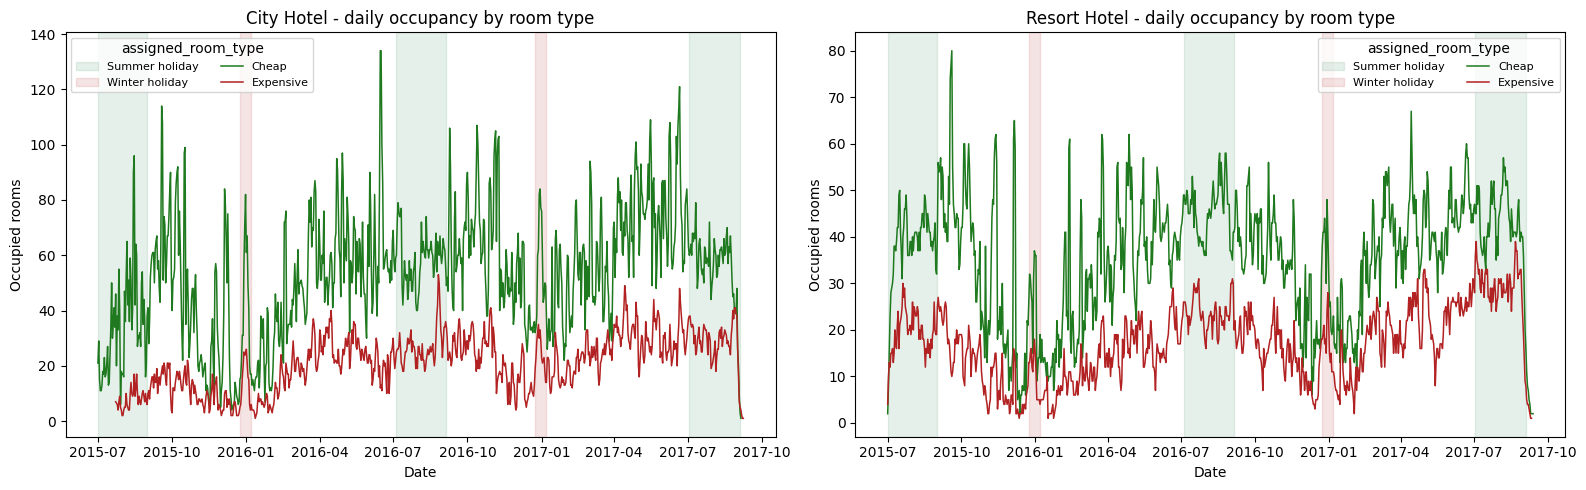

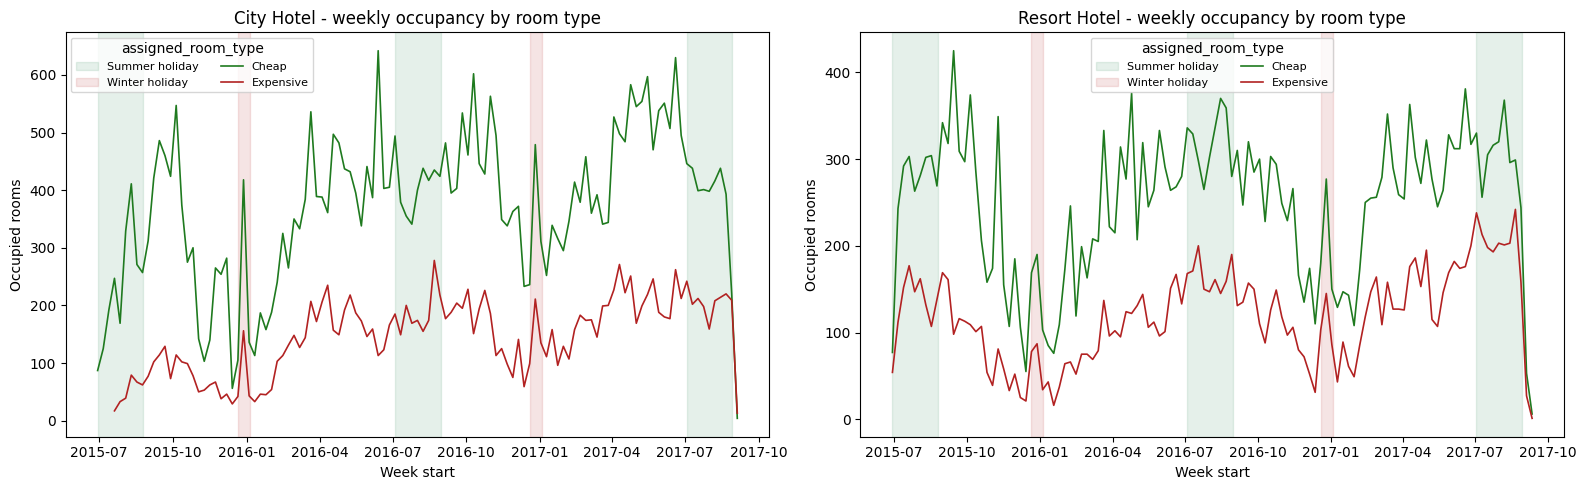

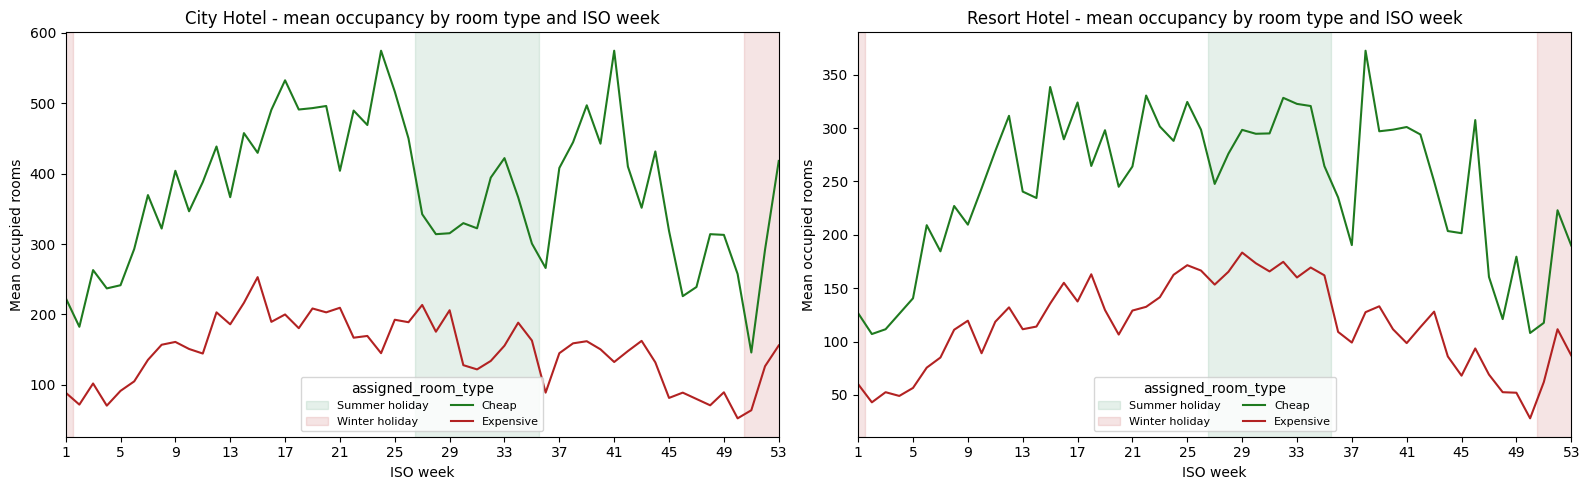

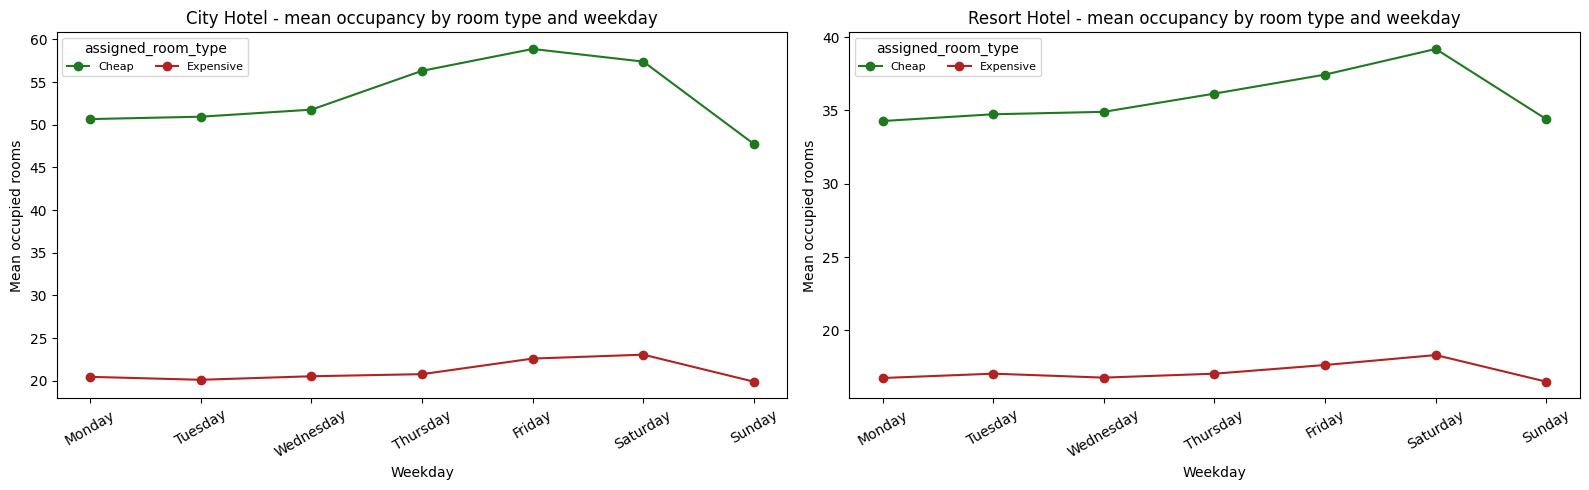

In [17]:
def addMarkedRanges(
    ax: Any,
    valueSeries: pd.Series,
    color: str,
    alpha: float,
    label: str,
    flagSeries: pd.Series | None = None,
    isNumericWeek: bool = False
) -> None:
    if flagSeries is not None:
        markerDf = pd.DataFrame({
            "value": pd.to_datetime(valueSeries),
            "flag": flagSeries
        }).sort_values("value")
        markerDf["start_flag"] = markerDf["flag"] & ~markerDf["flag"].shift(1, fill_value=False)
        markerDf["group_id"] = markerDf["start_flag"].cumsum()

        firstLabel = True
        for _, part in markerDf.loc[markerDf["flag"]].groupby("group_id"):
            startValue = part["value"].iloc[0]
            endValue = part["value"].iloc[-1] + pd.Timedelta(days=1)
            ax.axvspan(startValue, endValue, color=color, alpha=alpha, label=label if firstLabel else None)
            firstLabel = False
        return

    if isNumericWeek:
        weekValues = np.array(sorted({int(w) for w in valueSeries if pd.notna(w)}), dtype=int)
        if len(weekValues) == 0:
            return

        splitIdx = np.where(np.diff(weekValues) > 1)[0] + 1
        ranges = np.split(weekValues, splitIdx)

        firstLabel = True
        for part in ranges:
            startWeek = int(part[0])
            endWeek = int(part[-1])
            ax.axvspan(startWeek - 0.5, endWeek + 0.5, color=color, alpha=alpha, label=label if firstLabel else None)
            firstLabel = False


def buildHotelAxes(hotelValues: list[str], width: int = 8, height: int = 5) -> tuple[Any, np.ndarray]:
    fig, axes = plt.subplots(1, len(hotelValues), figsize=(width * len(hotelValues), height), sharey=False)
    return fig, np.atleast_1d(axes)


def getRoomColor(roomType: str) -> str:
    if roomType == "Cheap":
        return "#1f7a1f"
    if roomType == "Expensive":
        return "#b22222"
    return "#2e8b57"


def markSeasonsByDate(ax: Any, calendarDf: pd.DataFrame) -> None:
    addMarkedRanges(ax, calendarDf["stay_date"], "#2e8b57", 0.12, "Summer holiday", flagSeries=calendarDf["is_summer"])
    addMarkedRanges(ax, calendarDf["stay_date"], "#b22222", 0.12, "Winter holiday", flagSeries=calendarDf["is_winter"])


def markSeasonsByWeek(ax: Any, weeklyFlags: pd.DataFrame) -> None:
    summerWeeks = weeklyFlags.loc[weeklyFlags["is_summer"], "week_start"].dt.isocalendar().week.astype(int)
    winterWeeks = weeklyFlags.loc[weeklyFlags["is_winter"], "week_start"].dt.isocalendar().week.astype(int)
    addMarkedRanges(ax, summerWeeks, "#2e8b57", 0.12, "Summer holiday", isNumericWeek=True)
    addMarkedRanges(ax, winterWeeks, "#b22222", 0.12, "Winter holiday", isNumericWeek=True)


def plotDailyRoomLines(ax: Any, hotelDf: pd.DataFrame) -> None:
    for roomType in sorted(hotelDf["assigned_room_type"].dropna().unique()):
        roomDf = hotelDf.loc[hotelDf["assigned_room_type"] == roomType]
        ax.plot(roomDf["stay_date"], roomDf["occupied_rooms"], linewidth=1.1, color=getRoomColor(roomType), label=f"{roomType}")


def plotWeeklyRoomLines(ax: Any, hotelDf: pd.DataFrame) -> None:
    for roomType in sorted(hotelDf["assigned_room_type"].dropna().unique()):
        roomDf = hotelDf.loc[hotelDf["assigned_room_type"] == roomType].sort_values("week_start")
        ax.plot(roomDf["week_start"], roomDf["occupied_rooms"], linewidth=1.2, color=getRoomColor(roomType), label=f"{roomType}")


def plotIsoWeekRoomLines(ax: Any, hotelDf: pd.DataFrame) -> None:
    for roomType in sorted(hotelDf["assigned_room_type"].dropna().unique()):
        roomDf = hotelDf.loc[hotelDf["assigned_room_type"] == roomType]
        ax.plot(roomDf["iso_week"], roomDf["occupied_rooms"], linewidth=1.5, color=getRoomColor(roomType), label=f"{roomType}")


def plotWeekdayRoomLines(ax: Any, hotelDf: pd.DataFrame) -> None:
    for roomType in sorted(hotelDf["assigned_room_type"].dropna().unique()):
        roomDf = hotelDf.loc[hotelDf["assigned_room_type"] == roomType]
        ax.plot(roomDf["day_name"].astype(str), roomDf["occupied_rooms"], marker="o", linewidth=1.5, color=getRoomColor(roomType), label=f"{roomType}")


def styleOccupancyAxes(ax: Any, title: str, xlabel: str, ylabel: str) -> None:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title="assigned_room_type", ncol=2, fontsize=8)


def plotDailyOccupancyByRoom(hotelValues: list[str], dailyByRoom: pd.DataFrame, calendarDf: pd.DataFrame) -> None:
    fig, axes = buildHotelAxes(hotelValues)
    for idx, hotelName in enumerate(hotelValues):
        ax = axes[idx]
        hotelDf = dailyByRoom.loc[dailyByRoom["hotel"] == hotelName].copy()
        markSeasonsByDate(ax, calendarDf)
        plotDailyRoomLines(ax, hotelDf)
        styleOccupancyAxes(ax, f"{hotelName} - daily occupancy by room type", "Date", "Occupied rooms")

    plt.tight_layout()
    plt.show()


def plotWeeklyOccupancyByRoom(hotelValues: list[str], weeklyByRoom: pd.DataFrame, weeklyFlags: pd.DataFrame) -> None:
    fig, axes = buildHotelAxes(hotelValues)
    for idx, hotelName in enumerate(hotelValues):
        ax = axes[idx]
        hotelDf = weeklyByRoom.loc[weeklyByRoom["hotel"] == hotelName].copy()
        markSeasonsByDate(ax, weeklyFlags.rename(columns={"week_start": "stay_date"}))
        plotWeeklyRoomLines(ax, hotelDf)
        styleOccupancyAxes(ax, f"{hotelName} - weekly occupancy by room type", "Week start", "Occupied rooms")

    plt.tight_layout()
    plt.show()


def plotMeanOccupancyByIsoWeek(hotelValues: list[str], weekOfYearByRoom: pd.DataFrame, weeklyFlags: pd.DataFrame) -> None:
    fig, axes = buildHotelAxes(hotelValues)
    for idx, hotelName in enumerate(hotelValues):
        ax = axes[idx]
        hotelDf = weekOfYearByRoom.loc[weekOfYearByRoom["hotel"] == hotelName].copy()
        markSeasonsByWeek(ax, weeklyFlags)
        plotIsoWeekRoomLines(ax, hotelDf)

        styleOccupancyAxes(ax, f"{hotelName} - mean occupancy by room type and ISO week", "ISO week", "Mean occupied rooms")
        ax.set_xlim(1, 53)
        ax.set_xticks(np.arange(1, 54, 4))

    plt.tight_layout()
    plt.show()


def plotMeanOccupancyByWeekday(hotelValues: list[str], dayOfWeekByRoom: pd.DataFrame) -> None:
    fig, axes = buildHotelAxes(hotelValues)
    for idx, hotelName in enumerate(hotelValues):
        ax = axes[idx]
        hotelDf = dayOfWeekByRoom.loc[dayOfWeekByRoom["hotel"] == hotelName].copy()
        plotWeekdayRoomLines(ax, hotelDf)
        styleOccupancyAxes(ax, f"{hotelName} - mean occupancy by room type and weekday", "Weekday", "Mean occupied rooms")
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


def plotOccupancyByRoomType(givenDataFrame: pd.DataFrame) -> None:
    context = prepareOccupancyContext(givenDataFrame)
    hotelValues = context["hotelValues"]
    dailyByRoom = context["dailyByRoom"]
    weeklyByRoom = context["weeklyByRoom"]
    calendarDf = context["calendarDf"]
    weeklyFlags = context["weeklyFlags"]

    plotDailyOccupancyByRoom(hotelValues, dailyByRoom, calendarDf)
    plotWeeklyOccupancyByRoom(hotelValues, weeklyByRoom, weeklyFlags)


def plotAverageOccupancyByRoomType(givenDataFrame: pd.DataFrame) -> None:
    context = prepareOccupancyContext(givenDataFrame)
    hotelValues = context["hotelValues"]
    dayOfWeekByRoom = context["dayOfWeekByRoom"]
    weekOfYearByRoom = context["weekOfYearByRoom"]
    weeklyFlags = context["weeklyFlags"]

    plotMeanOccupancyByIsoWeek(hotelValues, weekOfYearByRoom, weeklyFlags)
    plotMeanOccupancyByWeekday(hotelValues, dayOfWeekByRoom)


plotOccupancyByRoomType(dataFrame)
plotAverageOccupancyByRoomType(dataFrame)

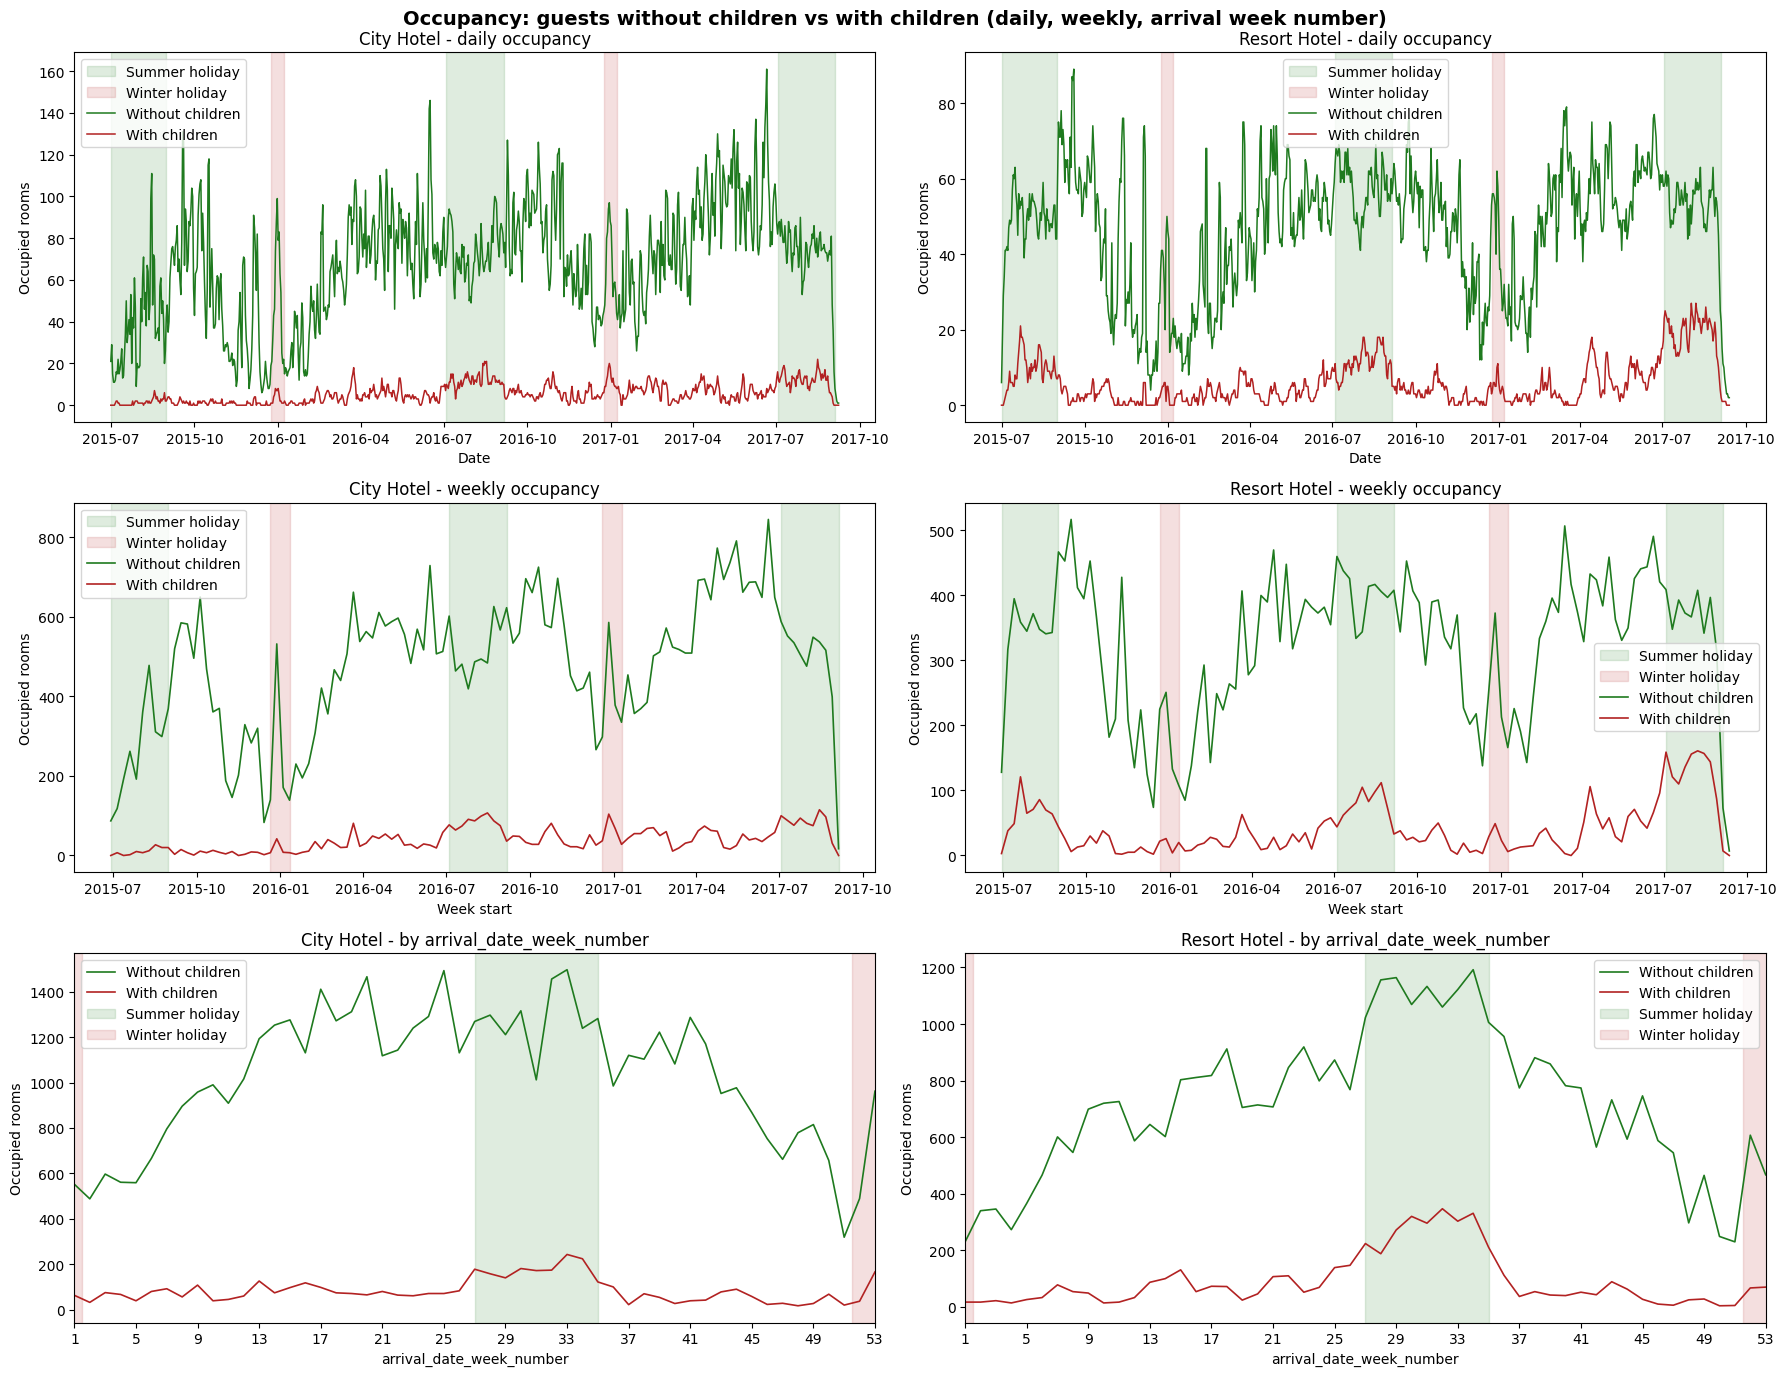

In [18]:
# Occupancy by guests with children vs without children (3x2 layout: rows = daily, weekly, arrival week number).

def prepareChildrenOccupancyBase(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    occupancyDf = givenDataFrame.copy()
    occupancyDf["arrival_date"] = pd.to_datetime(occupancyDf["arrival_date"], errors="coerce")
    occupancyDf["total_nights"] = (
        occupancyDf["stays_in_week_nights"].fillna(0) +
        occupancyDf["stays_in_weekend_nights"].fillna(0)
    ).astype(int)
    occupancyDf["children"] = occupancyDf["children"].fillna(0)
    occupancyDf["babies"] = occupancyDf["babies"].fillna(0)
    occupancyDf["guest_group"] = np.where(
        (occupancyDf["children"] + occupancyDf["babies"]) > 0,
        "With children",
        "Without children"
    )

    occupancyDf = occupancyDf[[
        "hotel",
        "arrival_date",
        "arrival_date_week_number",
        "total_nights",
        "guest_group"
    ]].copy()
    occupancyDf = occupancyDf.dropna(subset=["hotel", "arrival_date", "arrival_date_week_number"])
    return occupancyDf[occupancyDf["total_nights"] > 0].copy()


def expandChildrenOccupancyToDailyRows(occupancyDf: pd.DataFrame) -> pd.DataFrame:
    expandedDf = occupancyDf.loc[occupancyDf.index.repeat(occupancyDf["total_nights"])].copy()
    expandedDf["day_offset"] = expandedDf.groupby(level=0).cumcount()
    expandedDf["stay_date"] = expandedDf["arrival_date"] + pd.to_timedelta(expandedDf["day_offset"], unit="D")
    expandedDf["week_start"] = expandedDf["stay_date"] - pd.to_timedelta(expandedDf["stay_date"].dt.weekday, unit="D")
    expandedDf["arrival_date_week_number"] = expandedDf["arrival_date_week_number"].astype(int)
    return expandedDf


def markChildrenSeasonsByDate(ax: Any, dateSeries: pd.Series) -> None:
    markerDf = pd.DataFrame({"date": pd.to_datetime(dateSeries)}).sort_values("date")
    markerDf["iso_week"] = markerDf["date"].dt.isocalendar().week.astype(int)
    markerDf["is_summer"] = markerDf["iso_week"].between(27, 35)

    dateMonth = markerDf["date"].dt.month
    dateDay = markerDf["date"].dt.day
    markerDf["is_winter"] = ((dateMonth == 12) & (dateDay >= 24)) | ((dateMonth == 1) & (dateDay <= 6))

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        seasonDf = markerDf[["date", flagCol]].copy()
        seasonDf["group_id"] = (seasonDf[flagCol] != seasonDf[flagCol].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in seasonDf.groupby("group_id"):
            if not bool(part[flagCol].iloc[0]):
                continue
            startValue = part["date"].iloc[0]
            endValue = part["date"].iloc[-1] + pd.Timedelta(days=1)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.14, label=labelValue if firstLabel else None)
            firstLabel = False


def markChildrenSeasonsByWeek(ax: Any, weekStarts: pd.Series) -> None:
    markerDf = pd.DataFrame({"week_start": pd.to_datetime(weekStarts)}).sort_values("week_start")
    markerDf["iso_week"] = markerDf["week_start"].dt.isocalendar().week.astype(int)
    markerDf["is_summer"] = markerDf["iso_week"].between(27, 35)

    weeklyStarts = pd.to_datetime(markerDf["week_start"])
    weeklyEnds = weeklyStarts + pd.Timedelta(days=6)
    winterFlags = []
    for startValue, endValue in zip(weeklyStarts, weeklyEnds):
        yearValue = int(startValue.year)
        winterWindows = [
            (pd.Timestamp(year=yearValue - 1, month=12, day=24), pd.Timestamp(year=yearValue, month=1, day=6)),
            (pd.Timestamp(year=yearValue, month=12, day=24), pd.Timestamp(year=yearValue + 1, month=1, day=6)),
        ]
        overlapsWinter = any((startValue <= windowEnd) and (endValue >= windowStart) for windowStart, windowEnd in winterWindows)
        winterFlags.append(overlapsWinter)
    markerDf["is_winter"] = winterFlags

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        seasonDf = markerDf[["week_start", flagCol]].copy()
        seasonDf["group_id"] = (seasonDf[flagCol] != seasonDf[flagCol].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in seasonDf.groupby("group_id"):
            if not bool(part[flagCol].iloc[0]):
                continue
            startValue = part["week_start"].iloc[0]
            endValue = part["week_start"].iloc[-1] + pd.Timedelta(days=7)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.14, label=labelValue if firstLabel else None)
            firstLabel = False


def plotChildrenDaily(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    allDates = pd.date_range(hotelDf["stay_date"].min().normalize(), hotelDf["stay_date"].max().normalize(), freq="D")
    markChildrenSeasonsByDate(ax, allDates)

    for groupName, colorValue in [("Without children", "#1f7a1f"), ("With children", "#b22222")]:
        groupSeries = (
            hotelDf.loc[hotelDf["guest_group"] == groupName]
            .groupby("stay_date")
            .size()
            .reindex(allDates, fill_value=0)
        )
        ax.plot(groupSeries.index, groupSeries.values, color=colorValue, linewidth=1.1, label=groupName)

    ax.set_title(f"{hotelName} - daily occupancy")
    ax.set_xlabel("Date")
    ax.set_ylabel("Occupied rooms")
    ax.legend()


def plotChildrenWeekly(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    firstWeek = hotelDf["week_start"].min()
    lastWeek = hotelDf["week_start"].max()
    allWeekStarts = pd.date_range(firstWeek, lastWeek, freq="7D")
    markChildrenSeasonsByWeek(ax, allWeekStarts)

    for groupName, colorValue in [("Without children", "#1f7a1f"), ("With children", "#b22222")]:
        groupSeries = (
            hotelDf.loc[hotelDf["guest_group"] == groupName]
            .groupby("week_start")
            .size()
            .reindex(allWeekStarts, fill_value=0)
        )
        ax.plot(groupSeries.index, groupSeries.values, color=colorValue, linewidth=1.2, label=groupName)

    ax.set_title(f"{hotelName} - weekly occupancy")
    ax.set_xlabel("Week start")
    ax.set_ylabel("Occupied rooms")
    ax.legend()


def plotChildrenArrivalWeekNumber(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weekRange = np.arange(1, 54)
    for groupName, colorValue in [("Without children", "#1f7a1f"), ("With children", "#b22222")]:
        groupSeries = (
            hotelDf.loc[hotelDf["guest_group"] == groupName]
            .groupby("arrival_date_week_number")
            .size()
            .reindex(weekRange, fill_value=0)
        )
        ax.plot(weekRange, groupSeries.values, color=colorValue, linewidth=1.2, label=groupName)

    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.14, label="Summer holiday")
    ax.axvspan(51.5, 53.5, color="#b22222", alpha=0.14, label="Winter holiday")
    ax.axvspan(0.5, 1.5, color="#b22222", alpha=0.14)

    ax.set_title(f"{hotelName} - by arrival_date_week_number")
    ax.set_xlabel("arrival_date_week_number")
    ax.set_ylabel("Occupied rooms")
    ax.set_xlim(1, 53)
    ax.set_xticks(np.arange(1, 54, 4))
    ax.legend()


def plotChildrenOccupancyPanels(givenDataFrame: pd.DataFrame) -> None:
    occupancyDf = prepareChildrenOccupancyBase(givenDataFrame)
    expandedDf = expandChildrenOccupancyToDailyRows(occupancyDf)
    hotelValues = sorted(expandedDf["hotel"].dropna().unique())

    if len(hotelValues) != 2:
        raise ValueError(f"Expected exactly 2 hotels, got {len(hotelValues)}")

    fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharey=False)
    fig.suptitle(
        "Occupancy: guests without children vs with children (daily, weekly, arrival week number)",
        fontsize=14,
        fontweight="bold"
    )

    for colIdx, hotelName in enumerate(hotelValues):
        hotelDf = expandedDf.loc[expandedDf["hotel"] == hotelName].copy()
        plotChildrenDaily(axes[0, colIdx], hotelName, hotelDf)
        plotChildrenWeekly(axes[1, colIdx], hotelName, hotelDf)
        plotChildrenArrivalWeekNumber(axes[2, colIdx], hotelName, hotelDf)

    plt.tight_layout()
    plt.show()


plotChildrenOccupancyPanels(dataFrame)

In [ ]:
# Mean and median ADR over time, split by reservations with kids vs without kids.

def prepareAdrKidsBase(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    plotDf = givenDataFrame.copy()
    plotDf["arrival_date"] = pd.to_datetime(plotDf["arrival_date"], errors="coerce")
    plotDf["children"] = plotDf["children"].fillna(0)
    plotDf["babies"] = plotDf["babies"].fillna(0)
    plotDf = plotDf.dropna(subset=["hotel", "arrival_date", "adr"]).copy()
    plotDf["kids_group"] = np.where(
        (plotDf["children"] + plotDf["babies"]) > 0,
        "With kids",
        "Without kids"
    )
    return plotDf


def plotAdrKidsByDay(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    dailyAdr = (
        hotelDf.groupby(["arrival_date", "kids_group"])["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .sort_values("arrival_date")
    )
    allDates = pd.date_range(dailyAdr["arrival_date"].min(), dailyAdr["arrival_date"].max(), freq="D")
    addHolidayRangesByDate(ax, allDates)

    for groupName, colorValue in [("Without kids", "#1f7a1f"), ("With kids", "#b22222")]:
        groupDf = dailyAdr.loc[dailyAdr["kids_group"] == groupName].copy()
        ax.plot(groupDf["arrival_date"], groupDf["adr_mean"], color=colorValue, linewidth=1.5, label=f"{groupName} - mean ADR")
        ax.plot(groupDf["arrival_date"], groupDf["adr_median"], color=colorValue, linewidth=1.5, linestyle="--", label=f"{groupName} - median ADR")

    ax.set_title(f"{hotelName} - by day")
    ax.set_xlabel("Date")
    ax.set_ylabel("ADR")
    ax.legend(fontsize=8)


def plotAdrKidsByWeek(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyAdr = (
        hotelDf.groupby(["kids_group", pd.Grouper(key="arrival_date", freq="W-MON")], observed=False)["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .rename(columns={"arrival_date": "week_start"})
        .sort_values("week_start")
    )
    allWeekStarts = pd.date_range(weeklyAdr["week_start"].min(), weeklyAdr["week_start"].max(), freq="7D")
    addHolidayRangesByWeek(ax, allWeekStarts)

    for groupName, colorValue in [("Without kids", "#1f7a1f"), ("With kids", "#b22222")]:
        groupDf = weeklyAdr.loc[weeklyAdr["kids_group"] == groupName].copy()
        ax.plot(groupDf["week_start"], groupDf["adr_mean"], color=colorValue, linewidth=1.5, label=f"{groupName} - mean ADR")
        ax.plot(groupDf["week_start"], groupDf["adr_median"], color=colorValue, linewidth=1.5, linestyle="--", label=f"{groupName} - median ADR")

    ax.set_title(f"{hotelName} - weekly interval")
    ax.set_xlabel("Week start")
    ax.set_ylabel("ADR")
    ax.legend(fontsize=8)


def plotAdrKidsByWeekNumber(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyNumberAdr = (
        hotelDf[["arrival_date_week_number", "kids_group", "adr"]]
        .dropna()
        .groupby(["arrival_date_week_number", "kids_group"], observed=False)["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .sort_values("arrival_date_week_number")
    )

    for groupName, colorValue in [("Without kids", "#1f7a1f"), ("With kids", "#b22222")]:
        groupDf = weeklyNumberAdr.loc[weeklyNumberAdr["kids_group"] == groupName].copy()
        ax.plot(groupDf["arrival_date_week_number"], groupDf["adr_mean"], color=colorValue, linewidth=1.5, label=f"{groupName} - mean ADR")
        ax.plot(groupDf["arrival_date_week_number"], groupDf["adr_median"], color=colorValue, linewidth=1.5, linestyle="--", label=f"{groupName} - median ADR")

    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.14, label="Summer holiday")
    ax.axvspan(51.5, 53.5, color="#b22222", alpha=0.14, label="Winter holiday")
    ax.axvspan(0.5, 1.5, color="#b22222", alpha=0.14)

    ax.set_title(f"{hotelName} - by week number")
    ax.set_xlabel("arrival_date_week_number")
    ax.set_ylabel("ADR")
    ax.set_xlim(1, 53)
    ax.set_xticks(np.arange(1, 54, 4))
    ax.legend(fontsize=8)


def plotAdrByKidsPanels(givenDataFrame: pd.DataFrame) -> None:
    plotDf = prepareAdrKidsBase(givenDataFrame)
    hotelValues = sorted(plotDf["hotel"].dropna().unique())
    if len(hotelValues) != 2:
        raise ValueError(f"Expected exactly 2 hotels, got {len(hotelValues)}")

    fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharey=False)
    fig.suptitle(
        "Mean and median ADR by reservations with kids vs without kids: daily, weekly, and week number",
        fontsize=14,
        fontweight="bold"
    )

    for colIdx, hotelName in enumerate(hotelValues):
        hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
        plotAdrKidsByDay(axes[0, colIdx], hotelName, hotelDf)
        plotAdrKidsByWeek(axes[1, colIdx], hotelName, hotelDf)
        plotAdrKidsByWeekNumber(axes[2, colIdx], hotelName, hotelDf)

    plt.tight_layout()
    plt.show()


plotAdrByKidsPanels(dataFrame)

# Jak oplaca sie wspolpraca z agentami (tabela agent ma za duzo danych, rozwaz market_segment i distribution_channel, customer_type)
# Oplacalnosc klientow z dziecmi
# Oplacalnosc grup
# Wplyw depozytu na rezygnowalnosc, ale wez pod uwage date

### ADR comparison: reserved_room_type vs assigned_room_type

Dropped invalid rows: 10
Room match counts:
room_match
Same room type         26088
Different room type     3666


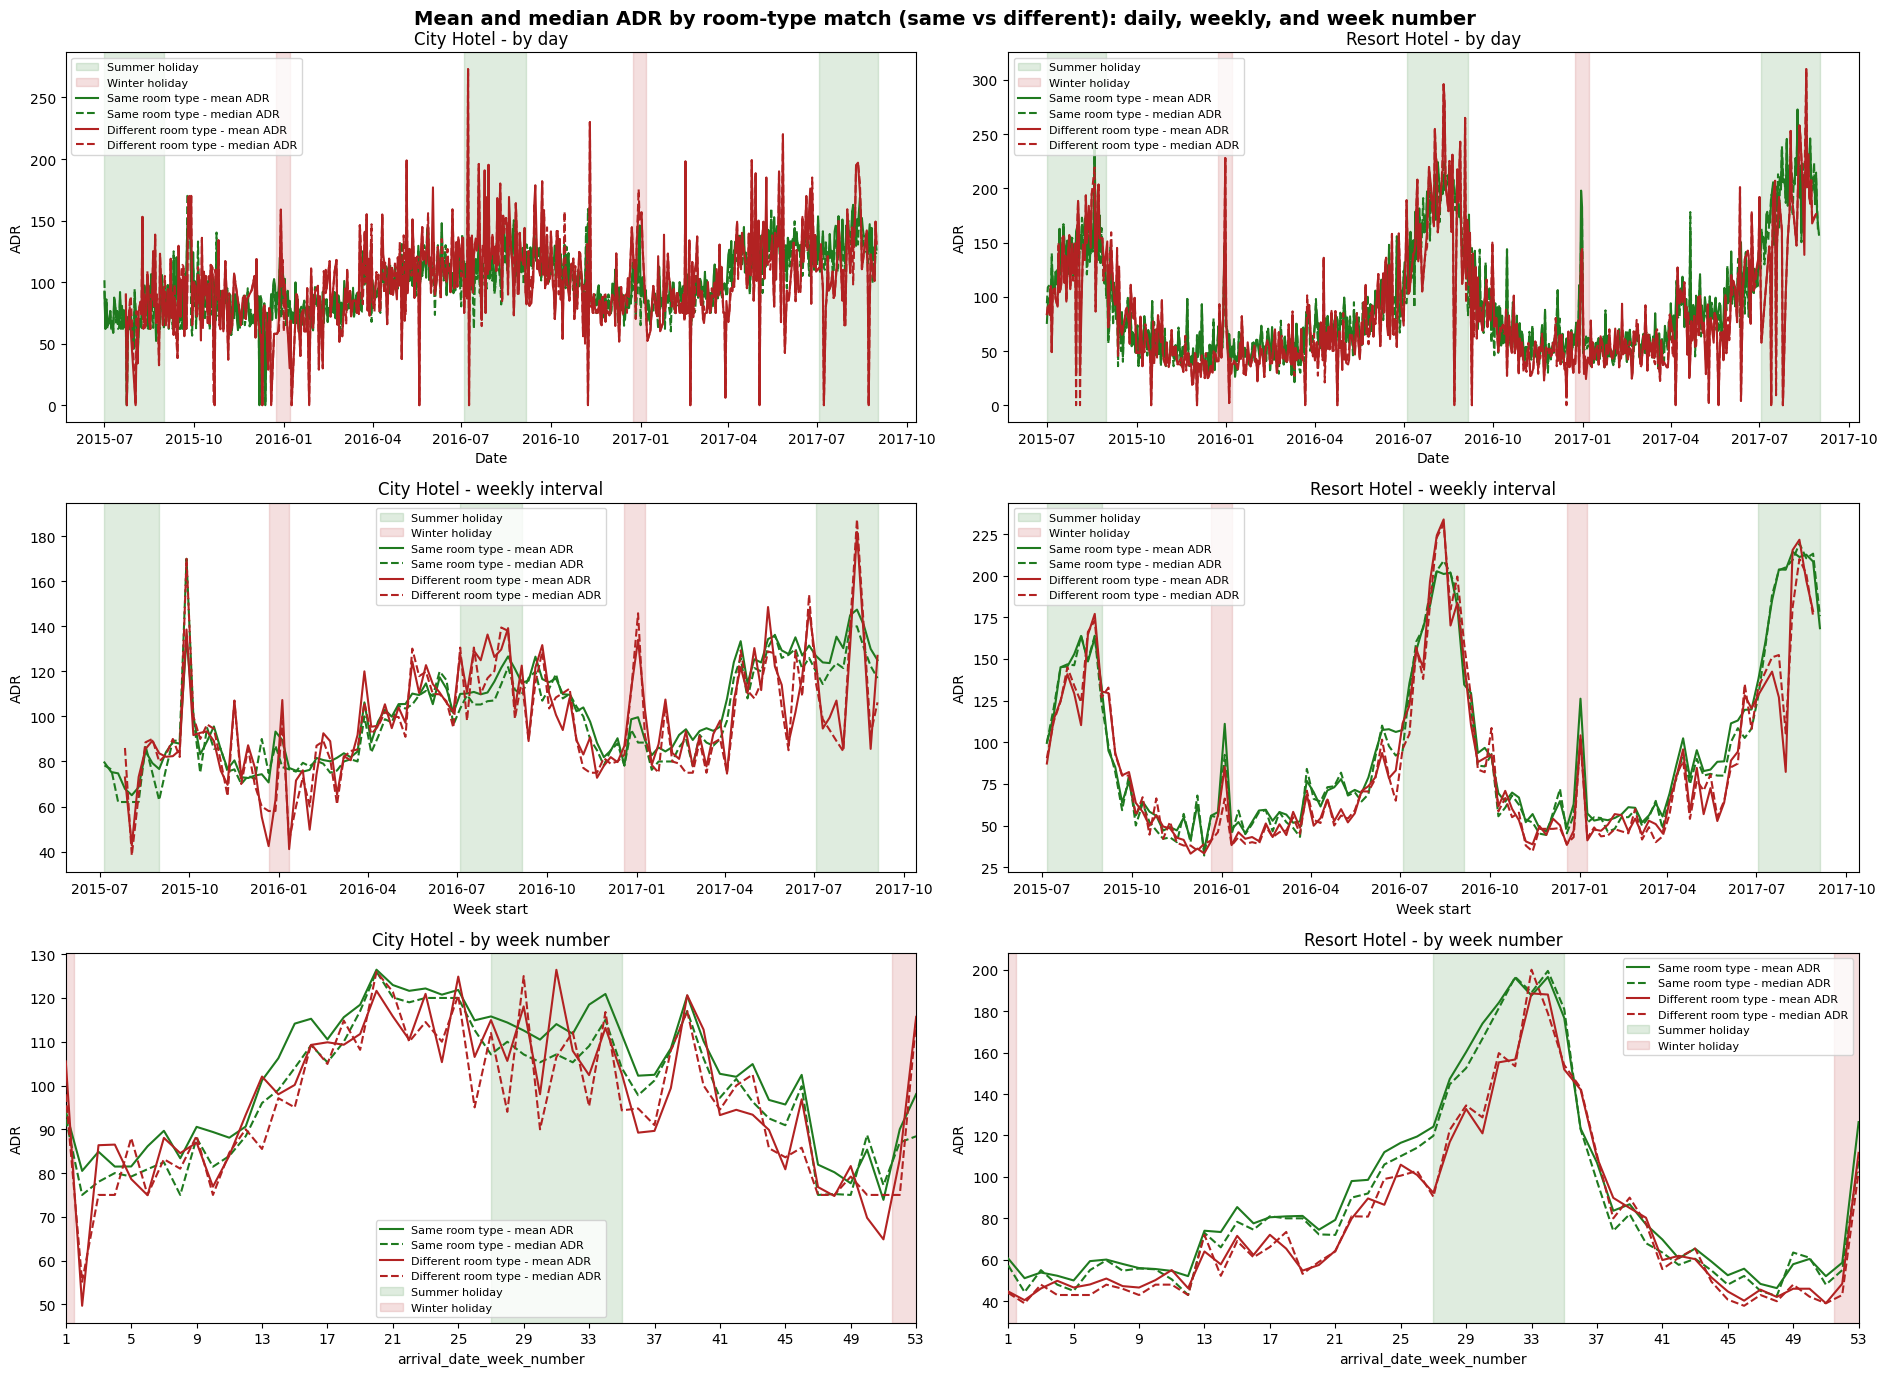

In [ ]:
# We remap room_types before, either show the plot earlier or make it use unmodified dataFrame (just like right  now)

def loadAdrComparisonDataFrame() -> pd.DataFrame:
    comparisonDf = pd.read_csv("./Dataset/hotel_bookings.csv").sample(30000, random_state=268555)
    comparisonDf.drop(columns=["company"], inplace=True)
    comparisonDf = comparisonDf.loc[comparisonDf["country"].notna()].copy()
    comparisonDf = comparisonDf.loc[comparisonDf["children"].notna()].copy()
    comparisonDf = prepareTimeColumns(comparisonDf)
    comparisonDf = comparisonDf[comparisonDf["adults"] != 0].copy()
    return comparisonDf


def prepareAdrRoomMatchBase() -> pd.DataFrame:
    plotDf = loadAdrComparisonDataFrame()
    plotDf = plotDf.dropna(subset=["hotel", "arrival_date", "adr", "reserved_room_type", "assigned_room_type"]).copy()
    plotDf["room_match"] = np.where(
        plotDf["reserved_room_type"] == plotDf["assigned_room_type"],
        "Same room type",
        "Different room type"
    )

    print("Room match counts:")
    print(plotDf["room_match"].value_counts().to_string())
    return plotDf


def addHolidayRangesByDate(ax: Any, dateSeries: pd.Series) -> None:
    markerDf = pd.DataFrame({"date": pd.to_datetime(dateSeries)}).sort_values("date")
    markerDf["iso_week"] = markerDf["date"].dt.isocalendar().week.astype(int)
    markerDf["is_summer"] = markerDf["iso_week"].between(27, 35)

    dateMonth = markerDf["date"].dt.month
    dateDay = markerDf["date"].dt.day
    markerDf["is_winter"] = ((dateMonth == 12) & (dateDay >= 24)) | ((dateMonth == 1) & (dateDay <= 6))

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        seasonDf = markerDf[["date", flagCol]].copy()
        seasonDf["group_id"] = (seasonDf[flagCol] != seasonDf[flagCol].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in seasonDf.groupby("group_id"):
            if not bool(part[flagCol].iloc[0]):
                continue
            startValue = part["date"].iloc[0]
            endValue = part["date"].iloc[-1] + pd.Timedelta(days=1)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.14, label=labelValue if firstLabel else None)
            firstLabel = False


def addHolidayRangesByWeek(ax: Any, weekStarts: pd.Series) -> None:
    markerDf = pd.DataFrame({"week_start": pd.to_datetime(weekStarts)}).sort_values("week_start")
    markerDf["iso_week"] = markerDf["week_start"].dt.isocalendar().week.astype(int)
    markerDf["is_summer"] = markerDf["iso_week"].between(27, 35)

    weeklyStarts = pd.to_datetime(markerDf["week_start"])
    weeklyEnds = weeklyStarts + pd.Timedelta(days=6)
    winterFlags = []
    for startValue, endValue in zip(weeklyStarts, weeklyEnds):
        yearValue = int(startValue.year)
        winterWindows = [
            (pd.Timestamp(year=yearValue - 1, month=12, day=24), pd.Timestamp(year=yearValue, month=1, day=6)),
            (pd.Timestamp(year=yearValue, month=12, day=24), pd.Timestamp(year=yearValue + 1, month=1, day=6)),
        ]
        overlapsWinter = any((startValue <= windowEnd) and (endValue >= windowStart) for windowStart, windowEnd in winterWindows)
        winterFlags.append(overlapsWinter)
    markerDf["is_winter"] = winterFlags

    for flagCol, colorValue, labelValue in [
        ("is_summer", "#1f7a1f", "Summer holiday"),
        ("is_winter", "#b22222", "Winter holiday"),
    ]:
        seasonDf = markerDf[["week_start", flagCol]].copy()
        seasonDf["group_id"] = (seasonDf[flagCol] != seasonDf[flagCol].shift(1, fill_value=False)).cumsum()

        firstLabel = True
        for _, part in seasonDf.groupby("group_id"):
            if not bool(part[flagCol].iloc[0]):
                continue
            startValue = part["week_start"].iloc[0]
            endValue = part["week_start"].iloc[-1] + pd.Timedelta(days=7)
            ax.axvspan(startValue, endValue, color=colorValue, alpha=0.14, label=labelValue if firstLabel else None)
            firstLabel = False


def plotAdrLinesByMatchStatus(ax: Any, plotData: pd.DataFrame, xCol: str) -> None:
    styleRules = [
        ("Same room type", "#1f7a1f"),
        ("Different room type", "#b22222"),
    ]
    for matchValue, colorValue in styleRules:
        matchDf = plotData.loc[plotData["room_match"] == matchValue].copy()
        if matchDf.empty:
            continue
        ax.plot(matchDf[xCol], matchDf["adr_mean"], color=colorValue, linewidth=1.5, label=f"{matchValue} - mean ADR", zorder=3)
        ax.plot(matchDf[xCol], matchDf["adr_median"], color=colorValue, linewidth=1.5, linestyle="--", label=f"{matchValue} - median ADR", zorder=3)


def plotAdrRoomMatchDaily(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    dailyAdr = (
        hotelDf.groupby(["arrival_date", "room_match"])["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .sort_values("arrival_date")
    )
    allDates = pd.date_range(dailyAdr["arrival_date"].min(), dailyAdr["arrival_date"].max(), freq="D")
    addHolidayRangesByDate(ax, allDates)
    plotAdrLinesByMatchStatus(ax, dailyAdr, "arrival_date")

    ax.set_title(f"{hotelName} - by day")
    ax.set_xlabel("Date")
    ax.set_ylabel("ADR")
    ax.legend(fontsize=8)


def plotAdrRoomMatchWeekly(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyAdr = (
        hotelDf.groupby(["room_match", pd.Grouper(key="arrival_date", freq="W-MON")], observed=False)["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .rename(columns={"arrival_date": "week_start"})
        .sort_values("week_start")
    )
    allWeekStarts = pd.date_range(weeklyAdr["week_start"].min(), weeklyAdr["week_start"].max(), freq="7D")
    addHolidayRangesByWeek(ax, allWeekStarts)
    plotAdrLinesByMatchStatus(ax, weeklyAdr, "week_start")

    ax.set_title(f"{hotelName} - weekly interval")
    ax.set_xlabel("Week start")
    ax.set_ylabel("ADR")
    ax.legend(fontsize=8)


def plotAdrRoomMatchWeekNumber(ax: Any, hotelName: str, hotelDf: pd.DataFrame) -> None:
    weeklyNumberAdr = (
        hotelDf[["arrival_date_week_number", "room_match", "adr"]]
        .dropna()
        .groupby(["arrival_date_week_number", "room_match"], observed=False)["adr"]
        .agg(adr_mean="mean", adr_median="median")
        .reset_index()
        .sort_values("arrival_date_week_number")
    )

    plotAdrLinesByMatchStatus(ax, weeklyNumberAdr, "arrival_date_week_number")
    ax.axvspan(27, 35, color="#1f7a1f", alpha=0.14, label="Summer holiday")
    ax.axvspan(51.5, 53.5, color="#b22222", alpha=0.14, label="Winter holiday")
    ax.axvspan(0.5, 1.5, color="#b22222", alpha=0.14)

    ax.set_title(f"{hotelName} - by week number")
    ax.set_xlabel("arrival_date_week_number")
    ax.set_ylabel("ADR")
    ax.set_xlim(1, 53)
    ax.set_xticks(np.arange(1, 54, 4))
    ax.legend(fontsize=8)


def plotAdrByRoomMatchPanels() -> None:
    plotDf = prepareAdrRoomMatchBase()
    hotelValues = sorted(plotDf["hotel"].unique())
    if len(hotelValues) != 2:
        raise ValueError(f"Expected exactly 2 hotels, got {len(hotelValues)}")

    fig, axes = plt.subplots(3, 2, figsize=(19, 14), sharey=False)
    fig.suptitle(
        "Mean and median ADR by room-type match (same vs different): daily, weekly, and week number",
        fontsize=14,
        fontweight="bold"
    )

    for colIdx, hotelName in enumerate(hotelValues):
        hotelDf = plotDf.loc[plotDf["hotel"] == hotelName].copy()
        plotAdrRoomMatchDaily(axes[0, colIdx], hotelName, hotelDf)
        plotAdrRoomMatchWeekly(axes[1, colIdx], hotelName, hotelDf)
        plotAdrRoomMatchWeekNumber(axes[2, colIdx], hotelName, hotelDf)

    plt.tight_layout()
    plt.show()


plotAdrByRoomMatchPanels()